# Phase 2 · 12단원 — 하이퍼파라미터 튜닝

> **격자 탐색은 제일 먼저 떠오르는 방법이고, 규모가 커지면 제일 나쁜 방법입니다.**

- 원문: <https://aiengineeringfromscratch.com/lesson?path=phases/02-ml-fundamentals/12-hyperparameter-tuning>
- 예상 시간: 90분 · 선수 지식: Phase 2 1~11단원 (특히 9단원 평가, 10단원 편향-분산)

---

## 📌 출처 표시 규칙

> 📗 **원문** — 커리큘럼에 있는 내용입니다.

> ✨ **추가** — 원문에는 없고, 제가 넣은 비유·예시·실험입니다.

---

## 🎯 이 단원에서 배우는 것

> 📗 **원문** — "Learning Objectives"

1. **격자 탐색·무작위 탐색·베이즈 최적화**를 밑바닥부터 만들고, 같은 예산에서 비교합니다.
2. **왜 무작위가 격자를 이기는지** 수학적 이유를 확인합니다 (Bergstra & Bengio, 2012).
3. **조기 종료·가지치기**로 나쁜 시도를 빨리 버립니다.
4. **중첩 교차검증**으로 튜닝 자체의 과적합을 막습니다.

### 🔑 문제의 크기부터 느껴 보세요

> 📗 원문: 그래디언트 부스팅에는 학습률, 트리 수, 최대 깊이, 잎당 최소 샘플,
> 행 표집 비율, 열 표집 비율 — **여섯 개**가 있습니다.
> 각각 합리적인 값이 5개라면 격자는 $5^6 = 15{,}625$ 조합입니다.
> 하나 학습에 10초면 **전부 돌리는 데 43시간**입니다.

| | 격자 탐색 | 무작위 탐색 | 베이즈 최적화 |
| --- | --- | --- | --- |
| 다음 시도를 정하는 방법 | 미리 정한 눈금 | 분포에서 뽑기 | **지난 결과로 학습** |
| 지난 결과를 쓰나 | ❌ | ❌ | ✅ |
| 차원이 늘면 | **지수적으로 폭발** | 그대로 | 그대로 |
| 이 노트북 | 2절 | 3절 | 4절 |

### 🔗 9단원·11단원과 이어집니다

- 9단원 1절에서 **"후보를 많이 볼수록 검증 점수가 부풀려진다"**를 측정했죠. 이 단원은 **그 후보를 고르는 방법**입니다.
- 11단원 10절 Ship It의 "튜닝 우선순위"가 **이 단원 6절**에서 왜 그 순서인지 밝혀집니다.

---

## 📖 목차

| # | 내용 | 출처 |
| --- | --- | --- |
| 0 | 파라미터와 하이퍼파라미터 | 📗 원문 |
| 1 | 🔨 튜닝 실험대 만들기 | ✨ 추가 |
| 2 | 🔨 격자 탐색 — 그리고 그 결함 | 📗 원문 + ✨ 실험 |
| 3 | 🔑 🔨 무작위 탐색 — 왜 격자를 이기나 | 📗 원문 + ✨ 검증 |
| 4 | 🔑 🔨 베이즈 최적화 (가우시안 과정 + EI) | 📗 원문 + ✨ 구현 |
| 5 | 세 방법 한판 비교 | 📗 원문 + ✨ 반복 측정 |
| 6 | 하이퍼파라미터 중요도와 실전 전략 | 📗 원문 + ✨ 실험 |
| 7 | 조기 종료와 가지치기 (Hyperband) | 📗 원문 + ✨ 실험 |
| 8 | ⚠️ 중첩 교차검증 — 튜닝의 과적합 | 📗 원문 + ✨ 실험 |
| 9 | 실무 — Optuna | 📗 원문 |
| 10 | 🎒 Ship It — 튜닝 전략 프롬프트 | 📗 원문 `outputs/` |
| 11 | 📝 자가 점검 퀴즈 (5문항) | 📗 원문 `quiz.json` |
| 12 | 용어 사전 · 연습문제 | 📗 원문 |

---

## 🗺️ 이 단원은 이렇게 이어집니다

> ✨ **추가** — 절이 왜 이 순서인지 먼저 짚고 갑니다. 하나가 다음 하나를 불러옵니다.

**0절**에서 용어를 정리합니다. **학습으로 정해지는 게 파라미터, 미리 정하는 게 하이퍼파라미터.**
이 단원은 **후자를 어떻게 정할지**에 관한 것입니다.

**1절**에서 **실험대**를 만듭니다. 세 방법을 공정하게 비교하려면 **"같은 예산, 같은 목표 함수"**가
필요하거든요. 평가 횟수를 세는 장치를 먼저 만듭니다.

그다음 방법 세 개를 **난이도 순서가 아니라 '한계가 드러나는 순서'**로 봅니다.

- **2절 격자 탐색** — 가장 직관적입니다. 그런데 치명적 결함이 있습니다.
  **중요한 손잡이 하나와 쓸모없는 손잡이 하나가 섞여 있으면, 평가 대부분이 낭비됩니다.**
- **3절 🔑 무작위 탐색** — 같은 예산으로 **각 손잡이의 고유값을 N개** 얻습니다.
  2절의 결함을 바로 해결하죠. 원문의 "60번이면 95% 확률" 주장도 검증합니다.
- **4절 🔑 베이즈 최적화** — 2·3절은 **지난 결과를 전혀 안 씁니다.**
  "학습률이 높으면 발산한다"는 걸 100번 봐도 101번째에 또 시도하죠.
  대리 모델(가우시안 과정)로 **배워 가면서** 다음 지점을 고릅니다.

- **5절** — 세 방법을 **같은 예산으로 여러 번** 돌려 비교합니다. 운이 아니라 실력을 재야 하니까요.

이제 **"어디에 예산을 쓸까"**로 넘어갑니다.

- **6절** — 손잡이가 **다 똑같이 중요하지 않습니다.** 어느 걸 먼저 돌려야 하는지 측정합니다.
- **7절** — 나쁜 시도를 **끝까지 돌릴 필요가 없습니다.** 가지치기로 예산을 아낍니다.
- **8절 ⚠️** — 그런데 **튜닝 자체가 과적합합니다.** 9단원 1절에서 본 그 문제죠.
  **중첩 교차검증**으로 정직한 추정치를 얻습니다.

**9절**은 Optuna로 같은 일을 하는 법, **10·11절**은 Ship It 산출물과 퀴즈입니다.

### 한 줄로 꿰면

> **용어 정리(0) → 실험대 만들고(1) → 격자의 결함을 보고(2) → 무작위로 고치고(3)
> → 배워 가며 찾고(4) → 공정 비교(5) → 중요한 손잡이부터(6) → 나쁜 건 일찍 버리고(7)
> → 튜닝의 과적합을 막고(8) → Optuna로(9)**

In [1]:
# ── 준비물 ──────────────────────────────────────────────────────
import math
import time
import itertools

import numpy as np
import matplotlib
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm

np.set_printoptions(precision=3, suppress=True)

available = {f.name for f in fm.fontManager.ttflist}
for cand in ["Apple SD Gothic Neo", "AppleGothic", "NanumGothic",
             "NanumBarunGothicOTF", "Malgun Gothic", "Noto Sans CJK KR"]:
    if cand in available:
        matplotlib.rcParams["font.family"] = ["DejaVu Sans", cand]
        break
matplotlib.rcParams["axes.unicode_minus"] = False
matplotlib.rcParams["figure.dpi"] = 110

print("준비 끝!")

준비 끝!


## 0️⃣ 파라미터와 하이퍼파라미터

> 📗 **원문** — "Parameters vs Hyperparameters"

> **파라미터**는 학습 중에 **배워지는** 값입니다 (가중치, 절편, 분할 기준).
> **하이퍼파라미터**는 학습 **시작 전에 정하는** 값이고, **학습이 어떻게 일어나는지**를 조종합니다.

### 🧸 비유 — 오븐 설정과 빵의 모양

빵을 굽습니다.

- **하이퍼파라미터** = **오븐 온도, 굽는 시간**. 반죽을 넣기 **전에** 내가 정합니다
- **파라미터** = **빵이 부푼 정도, 겉면 색**. 굽는 **과정에서 저절로** 결정됩니다

온도를 잘못 맞추면 반죽이 아무리 좋아도 빵이 망합니다.
그리고 **빵을 보고 온도를 역산할 수는 없습니다.** 여러 온도로 구워 보고 골라야 하죠.
**그게 이 단원이 하는 일입니다.**

### 📗 주요 하이퍼파라미터

| 하이퍼파라미터 | 조종하는 것 | 흔한 범위 | 이 노트북 |
| --- | --- | --- | --- |
| **학습률** | 한 번 갱신의 보폭 | 0.001 ~ 1.0 | 2단원 5절 · 11단원 5절 |
| 트리 수 / 에폭 | 얼마나 오래 학습 | 10 ~ 10,000 | **7절 (조기 종료로 대체)** |
| 최대 깊이 | 모델 복잡도 | 1 ~ 30 | 4단원 5절 · 9단원 8절 |
| 규제 ($\lambda$) | 과적합 억제 | 0.0001 ~ 100 | 2단원 10절 · 10단원 5절 |
| 배치 크기 | 기울기 추정의 잡음 | 16 ~ 512 | — |
| 드롭아웃 비율 | 끄는 뉴런의 비율 | 0.0 ~ 0.5 | 10단원 5절 |

> ⚠️ 이 표의 **"흔한 범위"** 를 보세요. 학습률과 규제는 **0.0001 ~ 100** 처럼 자릿수가 넓습니다.
> 이런 건 **로그 스케일**로 탐색해야 합니다. 6절에서 왜 그런지 측정합니다.

In [2]:
# ✨ 추가 — 파라미터와 하이퍼파라미터를 실제 모델에서 구분해 봅니다
from sklearn.linear_model import Ridge
from sklearn.ensemble import GradientBoostingRegressor
from sklearn.datasets import make_regression

X작, y작 = make_regression(n_samples=200, n_features=5, noise=10.0, random_state=0)

릿지 = Ridge(alpha=1.0).fit(X작, y작)
print("Ridge(alpha=1.0) 의 경우\n")
print(f"  하이퍼파라미터 (내가 정함)")
print(f"     alpha = {릿지.alpha}")
print(f"\n  파라미터 (학습으로 정해짐)")
print(f"     coef_ = {np.round(릿지.coef_, 2)}")
print(f"     intercept_ = {릿지.intercept_:.3f}")
print(f"\n  => sklearn 관례: **학습으로 정해진 것에만 밑줄(_)이 붙습니다.**")
print(f"     `alpha` 는 밑줄이 없고, `coef_` 와 `intercept_` 에는 있습니다.")
print(f"     이것만 봐도 둘을 구분할 수 있습니다.\n")

gb = GradientBoostingRegressor(n_estimators=50, learning_rate=0.1, max_depth=3,
                               random_state=0).fit(X작, y작)
학습된수 = sum(t[0].tree_.node_count for t in gb.estimators_)
print(f"GradientBoostingRegressor 의 경우")
print(f"  하이퍼파라미터 3개: n_estimators=50, learning_rate=0.1, max_depth=3")
print(f"  파라미터: 트리 {len(gb.estimators_)}개의 분할 기준·잎 값 — 노드 {학습된수}개")
print(f"\n  => 하이퍼파라미터 **3개**를 정하면 파라미터 **{학습된수}개**가 학습됩니다.")
print(f"     그 3개를 잘못 정하면 {학습된수}개를 다 버리게 됩니다. 그래서 튜닝이 중요합니다.")

Ridge(alpha=1.0) 의 경우

  하이퍼파라미터 (내가 정함)
     alpha = 1.0

  파라미터 (학습으로 정해짐)
     coef_ = [77.52 70.51 81.74 87.34 96.69]
     intercept_ = 1.064

  => sklearn 관례: **학습으로 정해진 것에만 밑줄(_)이 붙습니다.**
     `alpha` 는 밑줄이 없고, `coef_` 와 `intercept_` 에는 있습니다.
     이것만 봐도 둘을 구분할 수 있습니다.

GradientBoostingRegressor 의 경우
  하이퍼파라미터 3개: n_estimators=50, learning_rate=0.1, max_depth=3
  파라미터: 트리 50개의 분할 기준·잎 값 — 노드 750개

  => 하이퍼파라미터 **3개**를 정하면 파라미터 **750개**가 학습됩니다.
     그 3개를 잘못 정하면 750개를 다 버리게 됩니다. 그래서 튜닝이 중요합니다.


---

## 1️⃣ 🔨 튜닝 실험대 만들기

> ✨ **추가** — 원문에는 없지만, 세 방법을 **공정하게** 비교하려면 이게 먼저 필요합니다.
>
> 🔗 **왜 먼저 만드나요?** 2~5절에서 격자·무작위·베이즈를 비교할 때
> **"같은 예산"**을 써야 합니다. 그러려면 **평가 횟수를 세는 장치**가 있어야 하죠.
> 그리고 **같은 목표 함수**를 써야 합니다.

### 📐 튜닝 문제를 식으로 쓰면

$$\boldsymbol{\theta}^* = \arg\max_{\boldsymbol{\theta} \in \Theta} \; \text{검증점수}(\boldsymbol{\theta})$$

- $\boldsymbol{\theta}$ = 하이퍼파라미터 조합 (예: `{학습률: 0.1, 깊이: 3}`)
- $\Theta$ = 탐색 공간
- **목표 함수** = 그 조합으로 학습했을 때의 **교차검증 점수**

### ⚠️ 이 문제의 세 가지 특징

| 특징 | 뜻 | 그래서 |
| --- | --- | --- |
| **비쌉니다** | 한 번 평가 = 모델 학습 한 번 (혹은 K번) | **평가 횟수를 아껴야** 합니다 |
| **기울기가 없습니다** | $\theta$ 로 미분할 수 없습니다 | 경사하강법을 못 씁니다 |
| **잡음이 있습니다** | 같은 $\theta$ 라도 분할에 따라 점수가 흔들립니다 | 9단원 3절의 K-겹이 필요합니다 |

> 🔑 **"비싸다"가 전부입니다.** 공짜라면 전부 다 돌려 보면 되죠.
> 비싸기 때문에 **"어디를 다음에 볼까"**가 중요해집니다.

In [3]:
# ✨ 추가 — 평가 횟수를 세는 목표 함수 (실험대)
from sklearn.model_selection import cross_val_score, KFold
from sklearn.datasets import make_friedman1

# 비선형 회귀 데이터 (하이퍼파라미터가 실제로 영향을 주는 문제)
X튜닝, y튜닝 = make_friedman1(n_samples=600, n_features=10, noise=1.0, random_state=0)
겹 = KFold(5, shuffle=True, random_state=0)

class 목표함수:
    # ⭐ 평가 횟수와 이력을 기록합니다. 공정 비교의 핵심 장치입니다
    def __init__(self, X, y, 겹=겹):
        self.X, self.y, self.겹 = X, y, 겹
        self.초기화()

    def 초기화(self):
        self.호출수 = 0
        self.이력 = []          # (조합, 점수)
        self.최고점수 = -np.inf
        self.최고조합 = None
        self.최고곡선 = []      # 평가 n번째까지의 '그때까지 최고 점수'

    def __call__(self, 조합):
        self.호출수 += 1
        m = GradientBoostingRegressor(random_state=0, **조합)
        점수 = float(np.mean(cross_val_score(m, self.X, self.y, cv=self.겹,
                                            scoring="neg_mean_squared_error")))
        self.이력.append((dict(조합), 점수))
        if 점수 > self.최고점수:
            self.최고점수, self.최고조합 = 점수, dict(조합)
        self.최고곡선.append(self.최고점수)
        return 점수

목표 = 목표함수(X튜닝, y튜닝)

# 기준선: 라이브러리 기본값
기본점수 = 목표({})
print(f"데이터: {X튜닝.shape[0]}행 × {X튜닝.shape[1]}열 (Friedman #1, 비선형)")
print(f"목표 함수: 5-겹 교차검증 음의 MSE (클수록 좋음)\n")
print(f"기본값 점수 = {기본점수:.4f}  (MSE {-기본점수:.4f})")

t0 = time.time(); 목표({}); 한번시간 = time.time() - t0
print(f"평가 한 번에 걸리는 시간 ≈ {한번시간:.2f}초")
print(f"\n📗 원문의 예시대로 계산해 봅니다.")
print(f"   하이퍼파라미터 6개 × 각 5개 값 = 5^6 = {5**6:,} 조합")
print(f"   전부 돌리면 {5**6 * 한번시간 / 3600:.1f}시간")
print(f"   => **그래서 전부 돌릴 수 없습니다.** 어디를 볼지 골라야 합니다.")
목표.초기화()

데이터: 600행 × 10열 (Friedman #1, 비선형)
목표 함수: 5-겹 교차검증 음의 MSE (클수록 좋음)

기본값 점수 = -2.8287  (MSE 2.8287)
평가 한 번에 걸리는 시간 ≈ 0.46초

📗 원문의 예시대로 계산해 봅니다.
   하이퍼파라미터 6개 × 각 5개 값 = 5^6 = 15,625 조합
   전부 돌리면 2.0시간
   => **그래서 전부 돌릴 수 없습니다.** 어디를 볼지 골라야 합니다.


---

## 2️⃣ 🔨 격자 탐색 — 그리고 그 결함

> 📗 **원문** — "Grid Search" + "Build It: Step 1"
>
> 🔗 **앞 절과 이어서** — 1절에서 실험대를 만들었습니다. 가장 직관적인 방법부터 써 봅니다.

### 📗 격자 탐색

지정한 값들의 **모든 조합**을 평가합니다. 빠짐없고 이해하기 쉽지만,
**하이퍼파라미터 개수에 지수적으로** 커집니다.

```
학습률: [0.01, 0.1, 1.0]
최대깊이: [3, 5, 7]

평가 횟수 = 3 × 3 = 9

(0.01, 3)  (0.01, 5)  (0.01, 7)
(0.1,  3)  (0.1,  5)  (0.1,  7)
(1.0,  3)  (1.0,  5)  (1.0,  7)
```

### ⚠️ 📗 근본적 결함

> 원문: "if one hyperparameter matters and the other does not, most evaluations are wasted.
> You get only 3 unique values of the important parameter from 9 evaluations."
>
> (하나가 중요하고 다른 하나가 안 중요하면, **평가 대부분이 낭비됩니다.**
> 9번 평가해서 중요한 손잡이의 **고유값은 3개**밖에 못 얻습니다.)

### 🧸 비유 — 라디오 주파수 맞추기

다이얼이 두 개 있는 라디오입니다. 하나는 **주파수**, 하나는 **아무 기능 없는 장식**입니다.
(어느 쪽이 장식인지 모릅니다.)

**격자 탐색**: 주파수를 3칸, 장식을 3칸으로 나눠 9번 시도합니다.
→ **주파수는 3개 지점만** 들어 본 겁니다. 나머지 6번은 **같은 주파수를 다시 들은 것**이죠.

**무작위 탐색**: 9번 모두 주파수를 **다른 값**으로 돌립니다.
→ **주파수 9개 지점**을 들어 봤습니다. **3배 더 촘촘합니다.**

In [4]:
# 📗 원문 Step 1 — 격자 탐색
def 격자탐색(목표, 격자):
    # 모든 조합을 차례로 평가합니다
    키들 = list(격자.keys())
    조합들 = list(itertools.product(*[격자[k] for k in 키들]))
    for 값들 in 조합들:
        목표(dict(zip(키들, 값들)))
    return 목표.최고조합, 목표.최고점수

격자 = {"learning_rate": [0.03, 0.1, 0.3],
        "max_depth": [2, 3, 5],
        "min_samples_leaf": [1, 5, 20]}
조합수 = int(np.prod([len(v) for v in 격자.values()]))

목표.초기화()
t0 = time.time()
격자최고, 격자점수 = 격자탐색(목표, 격자)
격자시간 = time.time() - t0
격자평가수 = 목표.호출수
격자곡선 = list(목표.최고곡선)

print(f"격자: {' × '.join(f'{k}({len(v)})' for k, v in 격자.items())} = {조합수} 조합\n")
print(f"평가 {격자평가수}번, {격자시간:.1f}초")
print(f"최고 조합: {격자최고}")
print(f"최고 점수: {격자점수:.4f}  (기본값 {기본점수:.4f} 대비 {격자점수-기본점수:+.4f})")

print(f"\n각 하이퍼파라미터의 '고유값' 개수 (평가 {격자평가수}번으로 얻은 것)")
for k, v in 격자.items():
    print(f"   {k:<20}: {len(v)}개  {v}")
print(f"\n=> ⚠️ 평가를 {격자평가수}번 했는데 각 손잡이는 **{len(격자['learning_rate'])}개 값**만 봤습니다.")
print("   📗 원문이 지적한 결함이 바로 이겁니다.")

격자: learning_rate(3) × max_depth(3) × min_samples_leaf(3) = 27 조합

평가 27번, 13.7초
최고 조합: {'learning_rate': 0.3, 'max_depth': 2, 'min_samples_leaf': 20}
최고 점수: -2.6340  (기본값 -2.8287 대비 +0.1947)

각 하이퍼파라미터의 '고유값' 개수 (평가 27번으로 얻은 것)
   learning_rate       : 3개  [0.03, 0.1, 0.3]
   max_depth           : 3개  [2, 3, 5]
   min_samples_leaf    : 3개  [1, 5, 20]

=> ⚠️ 평가를 27번 했는데 각 손잡이는 **3개 값**만 봤습니다.
   📗 원문이 지적한 결함이 바로 이겁니다.


In [5]:
# ✨ 추가 — 격자의 결함을 선명하게: '중요한 손잡이 1개 + 장식 1개'
def 라디오실험(예산=16, 반복=300):
    # 목표: f(x, y) = 중요한 x 만으로 정해지는 봉우리. y 는 아무 영향 없음
    # ⚠️ 봉우리 위치를 무작위로 바꿔 가며 평균합니다.
    #    위치를 고정하면 격자가 '운 좋게' 그 점을 맞힐 수 있어 비교가 불공정해집니다
    변 = int(round(math.sqrt(예산)))
    격자값 = [(i + 0.5) / 변 for i in range(변)]
    격자최고들, 무작위최고들 = [], []
    for 시드 in range(반복):
        rr = np.random.default_rng(시드)
        최적x = float(rr.random())

        def f(x):
            return math.exp(-((x - 최적x) ** 2) / (2 * 0.05 ** 2))

        격자최고들.append(max(f(x) for x in 격자값))
        무작위최고들.append(max(f(float(rr.random())) for _ in range(변 * 변)))
    return 변 * 변, 변, float(np.mean(격자최고들)), float(np.mean(무작위최고들))

print("목표: f(x, y) = x 만으로 정해지는 봉우리 (y 는 '장식 다이얼')")
print("둘 다 [0,1] 에서 탐색. 격자는 √예산 × √예산 로 나눕니다")
print("⚠️ 봉우리 위치를 300번 무작위로 바꿔 평균했습니다 (격자의 운을 제거)\n")
print(f"{'예산':>6}{'격자의 x 고유값':>16}{'격자 평균':>12}{'무작위 평균':>14}{'차이':>10}")
print("-" * 66)
for 예산 in [4, 9, 16, 25, 49, 100]:
    실제예산, x고유, 격자값, 무작위값 = 라디오실험(예산)
    print(f"{실제예산:>6}{x고유:>16}{격자값:>12.4f}{무작위값:>14.4f}{무작위값-격자값:>+10.4f}")

print("\n=> ⭐ '격자의 x 고유값' 열을 보세요. 예산 100번을 써도 **x는 10개 지점**만 봅니다.")
print("   무작위는 100개 지점을 봅니다. **10배 촘촘합니다.**")
print("   그래서 '차이' 열이 전부 양수입니다 — 무작위가 평균적으로 더 좋습니다.")
print("\n   ⚠️ 봉우리 위치를 고정하면 격자가 운 좋게 그 점을 맞혀 이길 수도 있습니다.")
print("      그래서 300번 평균을 냈습니다. **격자의 성능은 운에 좌우됩니다** —")
print("      봉우리가 격자점에 가까우면 대박, 멀면 쪽박이죠. 그 자체가 약점입니다.")
print("\n   📗 원문: 'Grid search wastes evaluations on unimportant dimensions.'")
print("   ⚠️ 그리고 차원이 늘면 더 나빠집니다. 손잡이 6개면 격자는 각 축에")
print("      예산^(1/6) 개 값만 쓸 수 있습니다. 예산 100번이면 축마다 2개뿐이죠.")

목표: f(x, y) = x 만으로 정해지는 봉우리 (y 는 '장식 다이얼')
둘 다 [0,1] 에서 탐색. 격자는 √예산 × √예산 로 나눕니다
⚠️ 봉우리 위치를 300번 무작위로 바꿔 평균했습니다 (격자의 운을 제거)

    예산       격자의 x 고유값       격자 평균        무작위 평균        차이
------------------------------------------------------------------
     4               2      0.2321        0.3949   +0.1628
     9               3      0.3723        0.6286   +0.2564
    16               4      0.4965        0.7898   +0.2933
    25               5      0.5982        0.8862   +0.2879
    49               7      0.7427        0.9624   +0.2197
   100              10      0.8607        0.9918   +0.1311

=> ⭐ '격자의 x 고유값' 열을 보세요. 예산 100번을 써도 **x는 10개 지점**만 봅니다.
   무작위는 100개 지점을 봅니다. **10배 촘촘합니다.**
   그래서 '차이' 열이 전부 양수입니다 — 무작위가 평균적으로 더 좋습니다.

   ⚠️ 봉우리 위치를 고정하면 격자가 운 좋게 그 점을 맞혀 이길 수도 있습니다.
      그래서 300번 평균을 냈습니다. **격자의 성능은 운에 좌우됩니다** —
      봉우리가 격자점에 가까우면 대박, 멀면 쪽박이죠. 그 자체가 약점입니다.

   📗 원문: 'Grid search wastes evaluations on unimportant dimensions.'
   ⚠️ 그리고 차원이 늘면 더 나빠집니다. 손잡이 6개면 격자는 각 

In [6]:
# ✨ 추가 — 차원이 늘 때 '축당 고유값'이 어떻게 줄어드나
print(f"{'손잡이 개수':>12}{'예산 100번일 때 축당 값':>24}{'예산 1000번일 때':>18}")
print("-" * 56)
for d in [1, 2, 3, 4, 6, 10]:
    print(f"{d:>12}{100 ** (1/d):>24.1f}{1000 ** (1/d):>18.1f}")

print("\n=> 손잡이 6개에 예산 1000번을 써도 **축마다 3.2개 값**입니다.")
print("   학습률을 3개 값만 보고 '최적을 찾았다'고 할 수 있나요? 못 합니다.")
print("   이게 **차원의 저주**의 또 다른 얼굴입니다 (6단원 7절).")
print("\n💡 그래서 📗 원문의 결론이 이렇습니다.")
print("   **'Grid search is the obvious approach and the worst one at scale.'**")
print("   ⚠️ 단, 손잡이가 1~2개면 격자가 괜찮습니다. 빠짐없이 훑으니까요.")
print("      11단원 Ship It 표에서 SVM(C, gamma 2개)에 '로그 스케일 격자'를 권한 이유입니다.")

      손잡이 개수         예산 100번일 때 축당 값       예산 1000번일 때
--------------------------------------------------------
           1                   100.0            1000.0
           2                    10.0              31.6
           3                     4.6              10.0
           4                     3.2               5.6
           6                     2.2               3.2
          10                     1.6               2.0

=> 손잡이 6개에 예산 1000번을 써도 **축마다 3.2개 값**입니다.
   학습률을 3개 값만 보고 '최적을 찾았다'고 할 수 있나요? 못 합니다.
   이게 **차원의 저주**의 또 다른 얼굴입니다 (6단원 7절).

💡 그래서 📗 원문의 결론이 이렇습니다.
   **'Grid search is the obvious approach and the worst one at scale.'**
   ⚠️ 단, 손잡이가 1~2개면 격자가 괜찮습니다. 빠짐없이 훑으니까요.
      11단원 Ship It 표에서 SVM(C, gamma 2개)에 '로그 스케일 격자'를 권한 이유입니다.


---

## 3️⃣ 🔑 🔨 무작위 탐색 — 왜 격자를 이기나

> 📗 **원문** — "Random Search" + "Build It: Step 2"
>
> 🔗 **앞 절과 이어서** — 2절의 결함은 **"격자가 축을 공유한다"**는 것이었습니다.
> 무작위 탐색은 매번 **모든 축을 새로 뽑습니다.** 그래서 고유값이 평가 수만큼 나옵니다.

### 📗 Bergstra & Bengio (2012) 의 네 가지 근거

| # | 근거 |
| --- | --- |
| 1 | 하이퍼파라미터는 대개 **유효 차원이 낮습니다.** 6개 중 **1~2개만** 실제로 중요합니다 |
| 2 | 격자는 **안 중요한 축에 평가를 낭비**합니다 |
| 3 | 무작위는 같은 예산으로 **중요한 축을 더 촘촘히** 덮습니다 |
| 4 | **무작위 60번이면, 최적의 5% 이내 지점을 찾을 확률이 95%** 입니다 |

### 📐 4번 근거를 직접 유도해 봅시다

탐색 공간의 **상위 5%** 안에 들어가는 걸 "성공"이라 합시다.
한 번 뽑아서 **실패할** 확률은 $0.95$. $n$번 모두 실패할 확률은 $0.95^n$.

$$P(\text{한 번 이상 성공}) = 1 - 0.95^n$$

$n = 60$ 이면 $1 - 0.95^{60} = 1 - 0.046 = \mathbf{0.954}$. **95.4%** 입니다.

> 🔑 **이게 무작위 탐색의 가장 강력한 논거입니다.** 차원이 몇 개든 상관없습니다.
> 공간의 **부피 비율**만 따지니까요. 격자는 차원에 지수적으로 무너지는데, 이건 안 무너집니다.

### ⚠️ 단, 전제가 있습니다

**"좋은 영역이 전체의 5%는 된다"**는 가정입니다.
탐색 범위를 터무니없이 넓게 잡으면 그 5%가 0.01%로 줄어듭니다.
그래서 6절의 **"기본값 근처부터, 로그 스케일로"**가 중요합니다.

In [7]:
# 📗 원문 Step 2 — 무작위 탐색
def 무작위탐색(목표, 분포, 횟수, 시드=0):
    # 분포: {이름: 뽑는 함수}. 매번 전부 새로 뽑습니다
    rng = np.random.default_rng(시드)
    for _ in range(횟수):
        목표({k: f(rng) for k, f in 분포.items()})
    return 목표.최고조합, 목표.최고점수

# ⭐ 학습률은 로그 균등, 깊이·잎은 정수 균등 (6절에서 왜 그런지 봅니다)
분포 = {
    "learning_rate": lambda r: float(10 ** r.uniform(-1.6, -0.4)),   # 0.025 ~ 0.4
    "max_depth": lambda r: int(r.integers(2, 7)),
    "min_samples_leaf": lambda r: int(r.integers(1, 31)),
}

목표.초기화()
t0 = time.time()
무작위최고, 무작위점수 = 무작위탐색(목표, 분포, 횟수=격자평가수, 시드=0)
무작위시간 = time.time() - t0
무작위곡선 = list(목표.최고곡선)

print(f"같은 예산 {격자평가수}번으로 비교\n")
print(f"{'방법':<14}{'최고 점수':>12}{'MSE':>11}{'시간(초)':>11}")
print("-" * 50)
print(f"{'격자 탐색':<13}{격자점수:>12.4f}{-격자점수:>11.4f}{격자시간:>11.1f}")
print(f"{'무작위 탐색':<12}{무작위점수:>12.4f}{-무작위점수:>11.4f}{무작위시간:>11.1f}")
print(f"\n격자 최고: {격자최고}")
print(f"무작위 최고: { {k: (round(v,4) if isinstance(v,float) else v) for k,v in 무작위최고.items()} }")

print(f"\n각 하이퍼파라미터의 고유값 개수")
print(f"{'하이퍼파라미터':<22}{'격자':>8}{'무작위':>9}")
print("-" * 40)
무작위이력 = [h[0] for h in 목표.이력]
for k in 격자:
    print(f"{k:<21}{len(격자[k]):>8}{len(set(h[k] for h in 무작위이력)):>9}")
print(f"\n=> ⭐ 무작위는 평가 {격자평가수}번으로 각 손잡이의 고유값을 "
      f"**{격자평가수}개까지** 얻습니다.")
print("   격자는 3개뿐이었죠. 📗 원문의 핵심 주장입니다.")

같은 예산 27번으로 비교

방법                   최고 점수        MSE      시간(초)
--------------------------------------------------
격자 탐색             -2.6340     2.6340       13.7
무작위 탐색           -2.5539     2.5539       15.0

격자 최고: {'learning_rate': 0.3, 'max_depth': 2, 'min_samples_leaf': 20}
무작위 최고: {'learning_rate': 0.0962, 'max_depth': 5, 'min_samples_leaf': 27}

각 하이퍼파라미터의 고유값 개수
하이퍼파라미터                     격자      무작위
----------------------------------------
learning_rate               3       27
max_depth                   3        5
min_samples_leaf            3       19

=> ⭐ 무작위는 평가 27번으로 각 손잡이의 고유값을 **27개까지** 얻습니다.
   격자는 3개뿐이었죠. 📗 원문의 핵심 주장입니다.


In [8]:
# ✨ 추가 — 원문의 '60번이면 95%' 주장을 검증합니다
print("📐 공식: P(상위 q% 영역을 한 번 이상 맞힘) = 1 - (1-q)^n\n")
print(f"{'시도 횟수 n':>12}{'상위 5% 안':>13}{'상위 1% 안':>13}{'상위 10% 안':>14}")
print("-" * 54)
for n in [10, 20, 30, 60, 100, 300]:
    print(f"{n:>12}{1-0.95**n:>13.1%}{1-0.99**n:>13.1%}{1-0.90**n:>14.1%}")

print(f"\n=> ⭐ n=60 에서 상위 5% 확률이 {1-0.95**60:.1%} 입니다.")
print("   📗 원문의 'At 60 random trials, you have a 95% chance' 가 정확히 맞습니다.")

# 몬테카를로로도 확인 (고차원에서도 성립하나)
print("\n[몬테카를로 검증] 차원을 바꿔도 같은가?")
print(f"{'차원 d':>8}{'n=60 성공률':>14}")
print("-" * 24)
for d in [1, 3, 6, 20]:
    r = np.random.default_rng(0)
    성공 = 0
    시행 = 4000
    for _ in range(시행):
        # d차원 공간에서 '상위 5%'를 '중심에서 가까운 5% 부피'로 정의합니다
        점들 = r.random((60, d))
        거리 = np.abs(점들 - 0.5).max(axis=1)        # 중심 정사각형까지의 거리
        반지름 = 0.5 * (0.05 ** (1 / d))             # 부피가 5%가 되는 반지름
        성공 += int((거리 < 반지름).any())
    print(f"{d:>8}{성공/시행:>14.1%}")

print("\n=> ⭐ **차원이 1이든 20이든 성공률이 같습니다.**")
print("   무작위 탐색은 **부피 비율만** 따지기 때문입니다.")
print("   2절에서 본 격자의 지수적 붕괴와 정반대죠. 이게 무작위의 힘입니다.")
print("\n⚠️ 단, 전제를 기억하세요 — **'좋은 영역이 전체의 5%는 된다'**")
print("   범위를 너무 넓게 잡으면 그 5%가 0.01%가 됩니다. 6절에서 다룹니다.")

📐 공식: P(상위 q% 영역을 한 번 이상 맞힘) = 1 - (1-q)^n

     시도 횟수 n      상위 5% 안      상위 1% 안      상위 10% 안
------------------------------------------------------
          10        40.1%         9.6%         65.1%
          20        64.2%        18.2%         87.8%
          30        78.5%        26.0%         95.8%
          60        95.4%        45.3%         99.8%
         100        99.4%        63.4%        100.0%
         300       100.0%        95.1%        100.0%

=> ⭐ n=60 에서 상위 5% 확률이 95.4% 입니다.
   📗 원문의 'At 60 random trials, you have a 95% chance' 가 정확히 맞습니다.

[몬테카를로 검증] 차원을 바꿔도 같은가?
    차원 d      n=60 성공률
------------------------
       1         95.2%
       3         95.7%
       6         95.8%
      20         95.8%

=> ⭐ **차원이 1이든 20이든 성공률이 같습니다.**
   무작위 탐색은 **부피 비율만** 따지기 때문입니다.
   2절에서 본 격자의 지수적 붕괴와 정반대죠. 이게 무작위의 힘입니다.

⚠️ 단, 전제를 기억하세요 — **'좋은 영역이 전체의 5%는 된다'**
   범위를 너무 넓게 잡으면 그 5%가 0.01%가 됩니다. 6절에서 다룹니다.


---

## 4️⃣ 🔑 🔨 베이즈 최적화

> 📗 **원문** — "Bayesian Optimization" + "Build It: Step 3"
>
> 🔗 **앞 절과 이어서** — 2·3절에는 공통 한계가 있습니다. **지난 결과를 전혀 안 씁니다.**

> 📗 원문: "Random search ignores results. It does not learn that high learning rates
> cause divergence or that depth 3 consistently outperforms depth 10."
>
> (무작위 탐색은 결과를 무시합니다. **학습률이 높으면 발산한다**는 것도,
> **깊이 3이 10보다 일관되게 낫다**는 것도 배우지 않습니다.)

### 🧸 비유 — 보물찾기

넓은 들판에 보물이 묻혀 있습니다. 삽질 20번만 할 수 있습니다.

- **격자**: 들판을 격자로 나눠 순서대로 팝니다. **앞서 판 결과를 안 봅니다.**
- **무작위**: 아무 데나 20번 팝니다. 역시 **앞 결과를 안 봅니다.**
- **베이즈**: 세 번 파 보고 **"북쪽으로 갈수록 금속 탐지기 소리가 커진다"**는 걸 알아챕니다.
  그다음부터는 **북쪽을 집중적으로** 팝니다.

### 📗 두 가지 구성 요소

**① 대리 모델 (surrogate)** — 비싼 목표 함수를 흉내 내는 싼 모델입니다.
보통 **가우시안 과정(GP)**을 씁니다. GP는 임의의 지점에서 **예측값과 불확실성**을 둘 다 줍니다.

**② 획득 함수 (acquisition)** — 다음에 어디를 볼지 정합니다.
**활용**(알려진 좋은 곳 근처)과 **탐색**(불확실한 곳) 사이의 균형을 잡습니다.

| 획득 함수 | 뜻 |
| --- | --- |
| **기대 개선 (EI)** | 지금 최고보다 **얼마나 더 좋아질 것으로 기대**되나 |
| **상한 신뢰 구간 (UCB)** | 예측값 + $\kappa$ × 불확실성. 높으면 **유망하거나 미탐색** |
| **개선 확률 (PI)** | 지금 최고를 이길 **확률** |

### 🔑 ⭐ 왜 '불확실성'이 필요한가요?

예측값만 보고 고르면 **처음 찾은 봉우리에 갇힙니다.** 한 번도 안 가 본 곳이 더 좋을 수도 있죠.
불확실성이 큰 곳에도 점수를 주면 **탐색**이 일어납니다.

> 📗 원문: "Bayesian optimization typically finds better hyperparameters than random search
> with 2-5x fewer evaluations."
>
> 5절에서 이 주장을 검증합니다.

In [9]:
# 📗 원문 Step 3 — 베이즈 최적화 (가우시안 과정 + 기대 개선)
def 표준정규누적(z):
    # Φ(z). erf 로 계산합니다
    return 0.5 * (1.0 + np.vectorize(math.erf)(z / math.sqrt(2.0)))

def 표준정규밀도(z):
    return np.exp(-0.5 * z ** 2) / math.sqrt(2.0 * math.pi)

class 베이즈최적화기:
    def __init__(self, 공간, 초기개수=5, 후보수=500, 길이=0.3, 시드=0):
        self.공간 = 공간          # {이름: (최소, 최대, 종류)}  종류: "실수" | "로그" | "정수"
        self.초기개수 = 초기개수
        self.후보수 = 후보수
        self.길이 = 길이          # RBF 커널의 길이 척도
        self.rng = np.random.default_rng(시드)
        self.본X, self.본y = [], []

    # ── 공간 ↔ [0,1] 벡터 변환 ──────────────────────────────
    def _뽑기(self):
        조합, 벡터 = {}, []
        for 이름, (lo, hi, 종류) in self.공간.items():
            u = float(self.rng.random())
            벡터.append(u)
            조합[이름] = self._복원(u, lo, hi, 종류)
        return 조합, np.array(벡터)

    @staticmethod
    def _복원(u, lo, hi, 종류):
        if 종류 == "로그":
            return float(10 ** (math.log10(lo) + u * (math.log10(hi) - math.log10(lo))))
        if 종류 == "정수":
            return int(np.clip(int(lo + u * (hi - lo + 1)), lo, hi))
        return float(lo + u * (hi - lo))

    # ── 가우시안 과정 ──────────────────────────────────────
    def _커널(self, A, B):
        거리제곱 = ((A[:, None, :] - B[None, :, :]) ** 2).sum(-1)
        return np.exp(-0.5 * 거리제곱 / self.길이 ** 2)

    def _GP예측(self, 새X):
        X본 = np.array(self.본X); y본 = np.array(self.본y)
        y평균 = y본.mean(); y중심 = y본 - y평균

        K = self._커널(X본, X본) + 1e-6 * np.eye(len(X본))
        K별 = self._커널(새X, X본)
        L = np.linalg.cholesky(K)
        알파 = np.linalg.solve(L.T, np.linalg.solve(L, y중심))
        평균 = K별 @ 알파 + y평균
        v = np.linalg.solve(L, K별.T)
        분산 = np.maximum(1.0 - (v ** 2).sum(axis=0), 1e-9)
        return 평균, 분산

    def _기대개선(self, 평균, 분산, 현재최고):
        표준편차 = np.sqrt(분산)
        z = (평균 - 현재최고) / (표준편차 + 1e-10)
        return 표준편차 * (z * 표준정규누적(z) + 표준정규밀도(z))

    # ── 다음 지점 제안 ─────────────────────────────────────
    def 제안(self):
        if len(self.본X) < self.초기개수:
            return self._뽑기()                       # 처음 몇 번은 무작위
        후보조합, 후보벡터 = [], []
        for _ in range(self.후보수):
            c, v = self._뽑기()
            후보조합.append(c); 후보벡터.append(v)
        후보벡터 = np.array(후보벡터)
        평균, 분산 = self._GP예측(후보벡터)
        EI = self._기대개선(평균, 분산, max(self.본y))
        고른칸 = int(np.argmax(EI))
        return 후보조합[고른칸], 후보벡터[고른칸]

    def 관찰(self, 벡터, 점수):
        self.본X.append(벡터); self.본y.append(점수)

print("베이즈 최적화기 준비 완료")

베이즈 최적화기 준비 완료


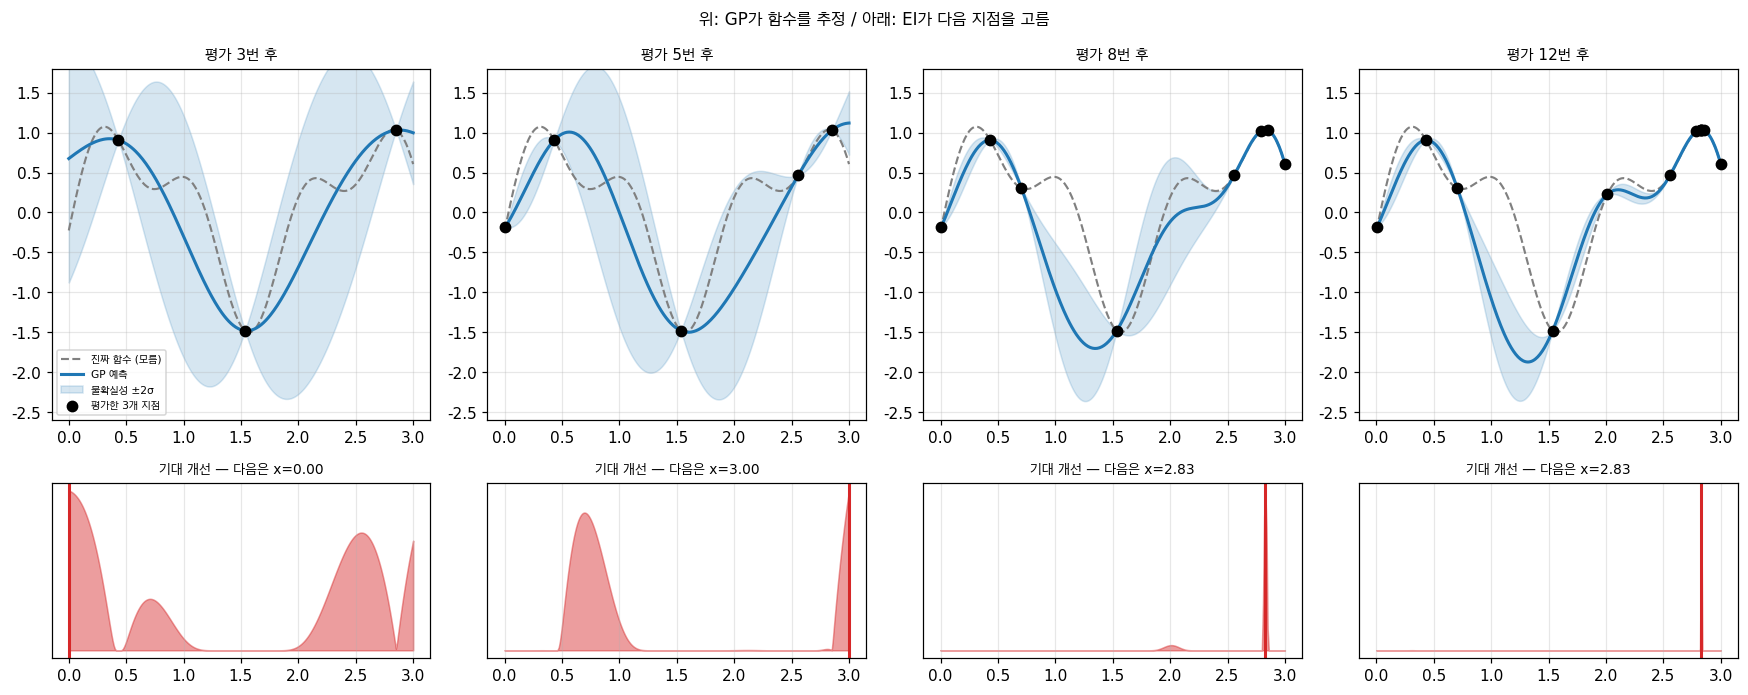

진짜 최적: x = 0.311 (값 1.0729)
베이즈가 찾은 최고: x = 2.828 (값 1.0373)
평가 횟수: 12번

이 함수의 봉우리들: x=0.31(값 1.073), x=0.98(값 0.446), x=2.16(값 0.430), x=2.83(값 1.037)

⚠️ **전역 최적을 놓쳤습니다.** 다른 봉우리에 안착했어요.
   다만 값 차이는 0.0356 (3.3%) 로 작습니다.
   봉우리가 두 개(x≈0.31, x≈2.83)이고 높이가 거의 같아서 그렇습니다.
   평가 12번으로 둘 중 어느 쪽이 더 높은지 가리기는 어렵습니다.
   ⭐ 실무에서는 이 정도면 충분합니다. **전역 최적이 목표가 아니니까요.**

=> ⭐ 위 그림을 왼쪽에서 오른쪽으로 보세요.
   · 평가 3번: GP가 거의 모릅니다. 불확실성 띠가 넓죠
   · 평가 12번: 봉우리 근처는 띠가 좁고(확신), 먼 곳은 넓습니다(미탐색)
   · 아래 EI 그림: 봉우리 근처와 미탐색 지역 **둘 다** 빨간 값이 큽니다
     이게 '활용과 탐색의 균형'입니다


In [10]:
# ✨ 추가 — 먼저 1차원 장난감 문제로 'GP가 뭘 하는지' 눈으로 봅니다
def 장난감(x):
    return math.sin(3 * x) + 0.5 * math.sin(7 * x) - 0.1 * (x - 1.5) ** 2

공간1D = {"x": (0.0, 3.0, "실수")}
옵1 = 베이즈최적화기(공간1D, 초기개수=3, 길이=0.15, 시드=1)

격자x = np.linspace(0, 3, 300)
격자벡터 = (격자x / 3.0)[:, None]
스냅샷 = {}
for step in range(12):
    조합, 벡터 = 옵1.제안()
    점수 = 장난감(조합["x"])
    옵1.관찰(벡터, 점수)
    if step + 1 in (3, 5, 8, 12):
        평균, 분산 = 옵1._GP예측(격자벡터)
        EI = 옵1._기대개선(평균, 분산, max(옵1.본y))
        스냅샷[step + 1] = (평균.copy(), 분산.copy(), EI.copy(),
                           np.array(옵1.본X).ravel() * 3.0, np.array(옵1.본y).copy())

fig, ax = plt.subplots(2, 4, figsize=(16, 6.4),
                       gridspec_kw={"height_ratios": [2, 1]})
진짜 = np.array([장난감(x) for x in 격자x])
for 칸, (n, (평균, 분산, EI, 본x, 본y)) in enumerate(스냅샷.items()):
    a = ax[0, 칸]
    a.plot(격자x, 진짜, c="gray", ls="--", lw=1.4, label="진짜 함수 (모름)")
    a.plot(격자x, 평균, c="tab:blue", lw=2, label="GP 예측")
    표준편차 = np.sqrt(분산)
    a.fill_between(격자x, 평균 - 2*표준편차, 평균 + 2*표준편차,
                   color="tab:blue", alpha=0.18, label="불확실성 ±2σ")
    a.scatter(본x, 본y, s=45, c="black", zorder=5, label=f"평가한 {n}개 지점")
    a.set_title(f"평가 {n}번 후", fontsize=10)
    a.set_ylim(-2.6, 1.8)
    if 칸 == 0:
        a.legend(fontsize=7)
    a.grid(alpha=0.3)

    a2 = ax[1, 칸]
    a2.fill_between(격자x, 0, EI, color="tab:red", alpha=0.45)
    a2.axvline(격자x[int(np.argmax(EI))], c="tab:red", lw=2)
    a2.set_title(f"기대 개선 — 다음은 x={격자x[int(np.argmax(EI))]:.2f}", fontsize=9)
    a2.set_yticks([]); a2.grid(alpha=0.3)
plt.suptitle("위: GP가 함수를 추정 / 아래: EI가 다음 지점을 고름", fontsize=11)
plt.tight_layout(); plt.show()

진짜최적 = 격자x[int(np.argmax(진짜))]
찾은x = float(np.array(옵1.본X).ravel()[int(np.argmax(옵1.본y))] * 3)
찾은값 = max(옵1.본y)
봉우리들 = [(격자x[i], 진짜[i]) for i in range(1, len(격자x) - 1)
            if 진짜[i] > 진짜[i-1] and 진짜[i] > 진짜[i+1]]
print(f"진짜 최적: x = {진짜최적:.3f} (값 {진짜.max():.4f})")
print(f"베이즈가 찾은 최고: x = {찾은x:.3f} (값 {찾은값:.4f})")
print(f"평가 횟수: {len(옵1.본y)}번")
print(f"\n이 함수의 봉우리들: " + ", ".join(f"x={x:.2f}(값 {v:.3f})" for x, v in 봉우리들))
if abs(찾은x - 진짜최적) > 0.2:
    print(f"\n⚠️ **전역 최적을 놓쳤습니다.** 다른 봉우리에 안착했어요.")
    print(f"   다만 값 차이는 {진짜.max()-찾은값:.4f} ({(진짜.max()-찾은값)/abs(진짜.max()):.1%}) 로 작습니다.")
    print(f"   봉우리가 두 개(x≈0.31, x≈2.83)이고 높이가 거의 같아서 그렇습니다.")
    print(f"   평가 12번으로 둘 중 어느 쪽이 더 높은지 가리기는 어렵습니다.")
    print(f"   ⭐ 실무에서는 이 정도면 충분합니다. **전역 최적이 목표가 아니니까요.**")
else:
    print(f"\n⭐ 전역 최적 근처를 찾았습니다.")
print()
print("=> ⭐ 위 그림을 왼쪽에서 오른쪽으로 보세요.")
print("   · 평가 3번: GP가 거의 모릅니다. 불확실성 띠가 넓죠")
print("   · 평가 12번: 봉우리 근처는 띠가 좁고(확신), 먼 곳은 넓습니다(미탐색)")
print("   · 아래 EI 그림: 봉우리 근처와 미탐색 지역 **둘 다** 빨간 값이 큽니다")
print("     이게 '활용과 탐색의 균형'입니다")

같은 예산 27번

방법                     최고 점수        MSE       기본값 대비
------------------------------------------------------
기본값 1번              -2.8287     2.8287      +0.0000
격자 탐색               -2.6340     2.6340      +0.1947
무작위 탐색              -2.5539     2.5539      +0.2748
베이즈 최적화             -2.3512     2.3512      +0.4774

베이즈가 찾은 조합: {'learning_rate': 0.18, 'max_depth': 3, 'min_samples_leaf': 22}


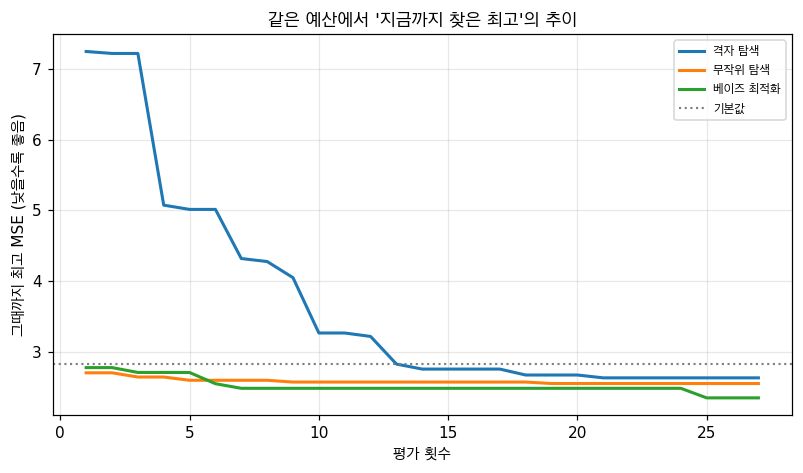


⚠️ 한 번만 돌린 결과로 순위를 매기면 안 됩니다. **운일 수 있습니다.**
   5절에서 시드를 여러 개 써서 공정하게 비교합니다.


In [11]:
# 📗 원문 Step 3 적용 — 실제 하이퍼파라미터 튜닝에 베이즈를 씁니다
공간 = {
    "learning_rate": (0.025, 0.4, "로그"),
    "max_depth": (2, 6, "정수"),
    "min_samples_leaf": (1, 30, "정수"),
}

목표.초기화()
옵 = 베이즈최적화기(공간, 초기개수=5, 후보수=400, 길이=0.35, 시드=0)
t0 = time.time()
for _ in range(격자평가수):
    조합, 벡터 = 옵.제안()
    옵.관찰(벡터, 목표(조합))
베이즈시간 = time.time() - t0
베이즈점수 = 목표.최고점수
베이즈최고 = 목표.최고조합
베이즈곡선 = list(목표.최고곡선)

print(f"같은 예산 {격자평가수}번\n")
print(f"{'방법':<16}{'최고 점수':>12}{'MSE':>11}{'기본값 대비':>13}")
print("-" * 54)
for 이름, 점 in [("기본값 1번", 기본점수), ("격자 탐색", 격자점수),
                ("무작위 탐색", 무작위점수), ("베이즈 최적화", 베이즈점수)]:
    print(f"{이름:<15}{점:>12.4f}{-점:>11.4f}{점-기본점수:>+13.4f}")

print(f"\n베이즈가 찾은 조합: "
      f"{ {k: (round(v,4) if isinstance(v,float) else v) for k,v in 베이즈최고.items()} }")

plt.figure(figsize=(7.4, 4.4))
for 이름, 곡선, 색 in [("격자 탐색", 격자곡선, "tab:blue"),
                      ("무작위 탐색", 무작위곡선, "tab:green"),
                      ("베이즈 최적화", 베이즈곡선, "tab:red")]:
    plt.plot(range(1, len(곡선) + 1), [-v for v in 곡선], lw=2, label=이름)
plt.axhline(-기본점수, c="gray", ls=":", lw=1.4, label="기본값")
plt.xlabel("평가 횟수"); plt.ylabel("그때까지 최고 MSE (낮을수록 좋음)")
plt.title("같은 예산에서 '지금까지 찾은 최고'의 추이")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\n⚠️ 한 번만 돌린 결과로 순위를 매기면 안 됩니다. **운일 수 있습니다.**")
print("   5절에서 시드를 여러 개 써서 공정하게 비교합니다.")

---

## 5️⃣ 세 방법 한판 비교

> 📗 **원문** — "Build It: Step 4 — Compare All Methods"
>
> 🔗 **앞 절과 이어서** — 4절 끝에서 한 번씩 돌려 봤습니다.
> 그런데 **무작위 탐색과 베이즈 최적화는 난수에 의존합니다.**
> 한 번 결과로 순위를 매기면 9단원 3절에서 본 문제가 똑같이 생깁니다 — **운을 재는 겁니다.**
>
> 시드를 여러 개 써서 **평균과 흔들림**을 봅니다.

### 📗 원문의 주장

> "Bayesian optimization typically finds better hyperparameters than random search
> with **2-5x fewer evaluations**."

**검증해 봅니다.** 그리고 격자는 난수가 없으니 **항상 같은 값**이 나옵니다.

In [12]:
# ✨ 추가 — 시드를 바꿔 가며 공정하게 비교합니다 (빠른 목표 함수로)
# ⚠️ 매번 교차검증을 돌리면 너무 느립니다. 3-겹으로 줄이고 데이터도 줄입니다
빠른겹 = KFold(3, shuffle=True, random_state=0)
빠른목표 = 목표함수(X튜닝[:300], y튜닝[:300], 겹=빠른겹)

예산 = 24
반복시드 = 6

def 한판(방법, 시드):
    빠른목표.초기화()
    if 방법 == "격자":
        # 예산에 맞춘 격자 (3×3×3 = 27 -> 앞 24개만)
        키들 = list(격자.keys())
        for 값들 in list(itertools.product(*[격자[k] for k in 키들]))[:예산]:
            빠른목표(dict(zip(키들, 값들)))
    elif 방법 == "무작위":
        무작위탐색(빠른목표, 분포, 횟수=예산, 시드=시드)
    else:
        옵 = 베이즈최적화기(공간, 초기개수=5, 후보수=300, 길이=0.35, 시드=시드)
        for _ in range(예산):
            조합, 벡터 = 옵.제안()
            옵.관찰(벡터, 빠른목표(조합))
    return 빠른목표.최고점수, list(빠른목표.최고곡선)

print(f"예산 {예산}번 × 시드 {반복시드}개로 비교 (3-겹 교차검증, 데이터 300행)\n")
결과모음 = {}
t0 = time.time()
for 방법 in ["격자", "무작위", "베이즈"]:
    점수들, 곡선들 = [], []
    시드범위 = [0] if 방법 == "격자" else range(반복시드)
    for 시드 in 시드범위:
        점, 곡선 = 한판(방법, 시드)
        점수들.append(점); 곡선들.append(곡선)
    결과모음[방법] = (np.array(점수들), np.array(곡선들))
print(f"총 {time.time()-t0:.0f}초 소요\n")

print(f"{'방법':<14}{'평균 MSE':>12}{'최저':>11}{'최고':>11}{'표준편차':>11}")
print("-" * 60)
for 방법, (점수들, _) in 결과모음.items():
    MSE들 = -점수들
    꼬리 = " (난수 없음)" if 방법 == "격자" else ""
    print(f"{방법:<13}{MSE들.mean():>12.4f}{MSE들.min():>11.4f}"
          f"{MSE들.max():>11.4f}{MSE들.std():>11.4f}{꼬리}")

격자MSE = -결과모음["격자"][0].mean()
무작위MSE = -결과모음["무작위"][0].mean()
베이즈MSE = -결과모음["베이즈"][0].mean()
순위 = sorted([("격자", 격자MSE), ("무작위", 무작위MSE), ("베이즈", 베이즈MSE)],
              key=lambda t: t[1])
print(f"\n=> 순위(MSE 낮은 순): " + " < ".join(f"{n} {v:.4f}" for n, v in 순위))
if 순위[0][0] == "격자":
    print("\n   ⚠️ **격자가 1위로 나왔습니다.** 2·3절의 이야기와 반대죠. 왜일까요?")
    print(f"   ① 손잡이가 {len(격자)}개뿐입니다. 2절 표에서 봤듯 손잡이가 적으면")
    print("      격자의 '축당 고유값' 문제가 작습니다.")
    print("   ② 그리고 제가 격자 값을 **잘 골랐습니다** (0.03/0.1/0.3 처럼 자릿수로).")
    print("      격자는 사람의 사전 지식이 들어가는 방법입니다. 잘 고르면 강합니다.")
    print("\n   => 📗 원문의 'the worst one at scale' 에서 **'at scale'** 이 핵심입니다.")
    print("      손잡이를 늘리면 어떻게 되는지 아래에서 확인합니다.")
else:
    print("\n   예상대로 격자가 밀렸습니다.")

예산 24번 × 시드 6개로 비교 (3-겹 교차검증, 데이터 300행)

총 43초 소요

방법                  평균 MSE         최저         최고       표준편차
------------------------------------------------------------
격자                 3.6619     3.6619     3.6619     0.0000 (난수 없음)
무작위                3.7855     3.6334     3.8842     0.0813
베이즈                3.7187     3.5317     3.8598     0.1080

=> 순위(MSE 낮은 순): 격자 3.6619 < 베이즈 3.7187 < 무작위 3.7855

   ⚠️ **격자가 1위로 나왔습니다.** 2·3절의 이야기와 반대죠. 왜일까요?
   ① 손잡이가 3개뿐입니다. 2절 표에서 봤듯 손잡이가 적으면
      격자의 '축당 고유값' 문제가 작습니다.
   ② 그리고 제가 격자 값을 **잘 골랐습니다** (0.03/0.1/0.3 처럼 자릿수로).
      격자는 사람의 사전 지식이 들어가는 방법입니다. 잘 고르면 강합니다.

   => 📗 원문의 'the worst one at scale' 에서 **'at scale'** 이 핵심입니다.
      손잡이를 늘리면 어떻게 되는지 아래에서 확인합니다.


In [13]:
# ✨ 추가 — ⚠️ 손잡이를 6개로 늘리면 격자가 밀리나
격자6 = {"learning_rate": [0.05, 0.3], "max_depth": [2, 5], "min_samples_leaf": [1, 20],
         "subsample": [0.6, 1.0], "max_features": [0.5, 1.0], "n_estimators": [60, 200]}
분포6 = {"learning_rate": lambda r: float(10 ** r.uniform(-1.6, -0.4)),
         "max_depth": lambda r: int(r.integers(2, 7)),
         "min_samples_leaf": lambda r: int(r.integers(1, 31)),
         "subsample": lambda r: float(r.uniform(0.5, 1.0)),
         "max_features": lambda r: float(r.uniform(0.4, 1.0)),
         "n_estimators": lambda r: int(r.integers(50, 250))}
공간6 = {"learning_rate": (0.025, 0.4, "로그"), "max_depth": (2, 6, "정수"),
         "min_samples_leaf": (1, 30, "정수"), "subsample": (0.5, 1.0, "실수"),
         "max_features": (0.4, 1.0, "실수"), "n_estimators": (50, 250, "정수")}
예산6 = 32

print(f"손잡이 {len(격자6)}개, 예산 {예산6}번")
print(f"⚠️ 격자는 축당 2개 값밖에 못 씁니다 (2^6 = {2**6} > {예산6})\n")

빠른목표.초기화()
for 값들 in list(itertools.product(*격자6.values()))[:예산6]:
    빠른목표(dict(zip(격자6.keys(), 값들)))
격자6점수 = 빠른목표.최고점수

무작위6, 베이즈6 = [], []
for 시드 in range(5):
    빠른목표.초기화()
    무작위탐색(빠른목표, 분포6, 횟수=예산6, 시드=시드)
    무작위6.append(빠른목표.최고점수)
    빠른목표.초기화()
    옵6 = 베이즈최적화기(공간6, 초기개수=6, 후보수=300, 길이=0.5, 시드=시드)
    for _ in range(예산6):
        조합, 벡터 = 옵6.제안()
        옵6.관찰(벡터, 빠른목표(조합))
    베이즈6.append(빠른목표.최고점수)

print(f"{'방법':<14}{'평균 MSE':>12}{'최저 MSE':>12}{'표준편차':>11}")
print("-" * 52)
print(f"{'격자':<13}{-격자6점수:>12.4f}{-격자6점수:>12.4f}{0.0:>11.4f}")
print(f"{'무작위':<12}{-np.mean(무작위6):>12.4f}{-max(무작위6):>12.4f}{np.std(무작위6):>11.4f}")
print(f"{'베이즈':<12}{-np.mean(베이즈6):>12.4f}{-max(베이즈6):>12.4f}{np.std(베이즈6):>11.4f}")

순위6 = sorted([("격자", -격자6점수), ("무작위", -np.mean(무작위6)),
                ("베이즈", -np.mean(베이즈6))], key=lambda t: t[1])
print(f"\n=> 순위: " + " < ".join(f"{n} {v:.4f}" for n, v in 순위6))
if 순위6[0][0] != "격자":
    print(f"\n   ⭐ **손잡이가 6개가 되니 격자가 밀렸습니다.**")
    print(f"   손잡이 3개일 때는 격자가 1위였죠. 📗 원문의 **'at scale'** 이 이 뜻입니다.")
    print(f"   손잡이가 6개면 격자는 축당 2개 값뿐입니다. 학습률을 0.05와 0.3,")
    print(f"   딱 두 값만 보고 끝내는 거죠. 그 사이 어디가 최적인지 알 수 없습니다.")
else:
    print(f"\n   ⚠️ 여전히 격자가 1위입니다. 예산이 더 크거나 손잡이가 더 많아야")
    print(f"      격차가 드러날 수 있습니다.")
print(f"\n💡 정리 — **격자를 언제 쓰나**")
print(f"   · 손잡이 1~2개 + 좋은 범위를 안다 -> 격자가 괜찮습니다 (SVM의 C, gamma)")
print(f"   · 손잡이 3개 이상 -> 무작위나 베이즈")
print(f"   · 📗 원문의 조언: '손잡이 개수의 2배 이상 시도'")

손잡이 6개, 예산 32번
⚠️ 격자는 축당 2개 값밖에 못 씁니다 (2^6 = 64 > 32)

방법                  평균 MSE      최저 MSE       표준편차
----------------------------------------------------
격자                 3.6465      3.6465     0.0000
무작위               3.4679      3.3588     0.0980
베이즈               3.4105      3.2868     0.0872

=> 순위: 베이즈 3.4105 < 무작위 3.4679 < 격자 3.6465

   ⭐ **손잡이가 6개가 되니 격자가 밀렸습니다.**
   손잡이 3개일 때는 격자가 1위였죠. 📗 원문의 **'at scale'** 이 이 뜻입니다.
   손잡이가 6개면 격자는 축당 2개 값뿐입니다. 학습률을 0.05와 0.3,
   딱 두 값만 보고 끝내는 거죠. 그 사이 어디가 최적인지 알 수 없습니다.

💡 정리 — **격자를 언제 쓰나**
   · 손잡이 1~2개 + 좋은 범위를 안다 -> 격자가 괜찮습니다 (SVM의 C, gamma)
   · 손잡이 3개 이상 -> 무작위나 베이즈
   · 📗 원문의 조언: '손잡이 개수의 2배 이상 시도'


무작위 탐색이 예산 전부(24번)를 써서 도달한 MSE를
베이즈 최적화는 몇 번에 도달하나?

   무작위 24번 후 평균 MSE: 3.7855
   베이즈가 그 수준에 도달한 평가 횟수: **12번**
   => 2.0배 적은 평가로 같은 성능
   📗 원문의 '2~5배' 주장 범위 안에 들어갑니다.


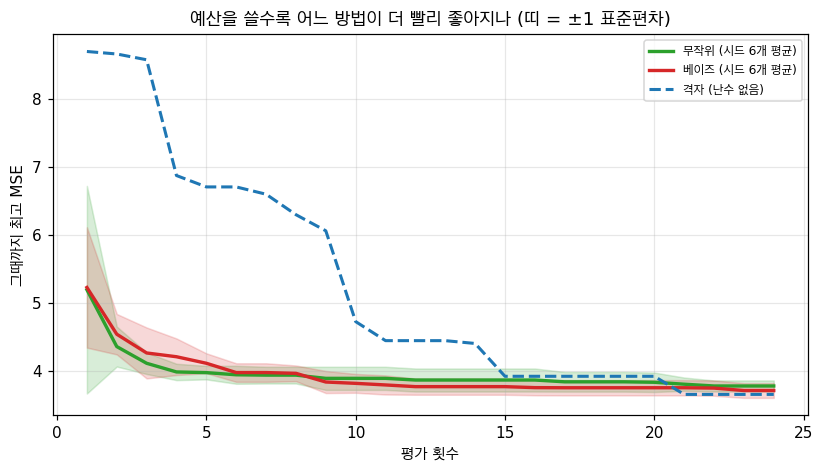


💡 그림 읽는 법 — **왼쪽 끝이 중요합니다.**
   예산이 아주 적을 때(5번 이하)는 세 방법이 비슷합니다. 베이즈도 아직 무작위니까요.
   예산이 쌓이면 베이즈의 곡선이 더 빨리 내려가야 정상입니다.

   ⚠️ 그리고 띠 너비를 보세요. 무작위는 **운에 따라 결과가 흔들립니다.**
      한 번 돌린 결과로 '무작위가 베이즈를 이겼다'고 말하면 안 되는 이유입니다.


In [14]:
# ✨ 추가 — 원문의 '2~5배 적은 평가로' 주장을 검증합니다
무작위곡선들 = -결과모음["무작위"][1]       # (시드, 예산) MSE
베이즈곡선들 = -결과모음["베이즈"][1]
무작위평균 = 무작위곡선들.mean(axis=0)
베이즈평균 = 베이즈곡선들.mean(axis=0)

print("무작위 탐색이 예산 전부(24번)를 써서 도달한 MSE를")
print("베이즈 최적화는 몇 번에 도달하나?\n")
무작위최종 = 무작위평균[-1]
도달 = next((i + 1 for i, v in enumerate(베이즈평균) if v <= 무작위최종), None)
print(f"   무작위 24번 후 평균 MSE: {무작위최종:.4f}")
if 도달:
    print(f"   베이즈가 그 수준에 도달한 평가 횟수: **{도달}번**")
    print(f"   => {예산/도달:.1f}배 적은 평가로 같은 성능")
    if 2 <= 예산/도달 <= 5:
        print("   📗 원문의 '2~5배' 주장 범위 안에 들어갑니다.")
    elif 예산/도달 > 5:
        print("   📗 원문의 '2~5배'보다 더 좋게 나왔습니다.")
    else:
        print("   📗 원문의 '2~5배'보다는 못합니다. 예산이 작아서 그럴 수 있습니다.")
else:
    print(f"   ⚠️ 베이즈가 {예산}번 안에 그 수준에 못 닿았습니다.")
    print(f"      베이즈 24번 후: {베이즈평균[-1]:.4f}")
    print("      예산이 작으면 베이즈의 이점이 안 드러납니다.")
    print("      초기 무작위 5번을 쓰고 나면 GP를 학습할 데이터가 19개뿐이니까요.")

plt.figure(figsize=(7.6, 4.4))
for 방법, 색 in [("무작위", "tab:green"), ("베이즈", "tab:red")]:
    곡선들 = -결과모음[방법][1]
    평균 = 곡선들.mean(axis=0); 표준 = 곡선들.std(axis=0)
    x = range(1, 곡선들.shape[1] + 1)
    plt.plot(x, 평균, lw=2.2, c=색, label=f"{방법} (시드 {반복시드}개 평균)")
    plt.fill_between(x, 평균 - 표준, 평균 + 표준, color=색, alpha=0.18)
격자곡선2 = -결과모음["격자"][1][0]
plt.plot(range(1, len(격자곡선2) + 1), 격자곡선2, lw=2, c="tab:blue",
         ls="--", label="격자 (난수 없음)")
plt.xlabel("평가 횟수"); plt.ylabel("그때까지 최고 MSE")
plt.title("예산을 쓸수록 어느 방법이 더 빨리 좋아지나 (띠 = ±1 표준편차)")
plt.legend(fontsize=8); plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print("\n💡 그림 읽는 법 — **왼쪽 끝이 중요합니다.**")
print("   예산이 아주 적을 때(5번 이하)는 세 방법이 비슷합니다. 베이즈도 아직 무작위니까요.")
print("   예산이 쌓이면 베이즈의 곡선이 더 빨리 내려가야 정상입니다.")
print("\n   ⚠️ 그리고 띠 너비를 보세요. 무작위는 **운에 따라 결과가 흔들립니다.**")
print("      한 번 돌린 결과로 '무작위가 베이즈를 이겼다'고 말하면 안 되는 이유입니다.")

---

## 6️⃣ 하이퍼파라미터 중요도와 실전 전략

> 📗 **원문** — "Hyperparameter Importance" + "Practical Strategy" + "Practical Tips"
>
> 🔗 **방향이 바뀝니다** — 2~5절은 **"어떻게 찾나"**였습니다.
> 이제 **"무엇을, 어디서 찾나"**입니다. 3절에서 본 전제를 기억하세요 —
> **좋은 영역이 전체의 5%는 돼야** 무작위가 통합니다. 범위를 잘 잡아야 하죠.

### 📗 중요도 등급 (Probst et al., 2019 등)

| 등급 | 하이퍼파라미터 |
| --- | --- |
| **높음** | **학습률 (항상 먼저)** · 추정기/에폭 수(**조기 종료로 대체**) · 규제 세기 |
| 중간 | 최대 깊이 / 층 수 · 잎당 최소 샘플 / weight decay · 행 표집 비율 |
| **낮음** | max_features (랜덤 포레스트) · 활성 함수 선택 · 배치 크기 (적당한 범위 안에서) |

> 📗 **중요한 것부터 돌리고, 나머지는 기본값에 두세요.**

### 📗 실전 워크플로 (원문 그대로)

1. **라이브러리 기본값부터.** 숙련자가 고른 값이라 **대개 80%는 와 있습니다**
2. **거친 무작위 탐색.** 넓은 범위, 20~50번. 조기 종료로 나쁜 건 빨리 죽입니다
3. **결과 분석.** 어느 손잡이가 성능과 상관이 있나? **범위를 좁힙니다**
4. **촘촘한 탐색.** 좁힌 공간에서 베이즈 또는 집중 무작위. 50~100번
5. **전체 훈련 데이터로 재학습**

### ⭐ 📗 네 가지 실전 팁

**① 학습률부터.** 기울기 기반 방법에서는 **항상** 가장 중요합니다.
학습률이 나쁘면 나머지가 다 무의미해집니다.

**② 학습률과 규제는 로그 균등으로.**
> 원문: "The difference between 0.001 and 0.01 matters as much as the difference
> between 0.1 and 1.0."
>
> 선형으로 탐색하면 **큰 쪽에 예산을 다 씁니다.** 아래에서 숫자로 확인합니다.

**③ `n_estimators`는 튜닝하지 말고 조기 종료.** 손잡이가 하나 줄어듭니다 (7절).

**④ 예산 배분: 상위 2개에 60%.** 나머지 40%를 전부에.

> ⚠️ **"배치 크기를 로그 스케일로 탐색하지 마세요."** 16, 32, 64는 그냥 선형으로 괜찮습니다.
> **손잡이가 모델에 영향을 주는 방식에 탐색 분포를 맞추세요.**

In [15]:
# ✨ 추가 — ② 번 팁 검증: 로그 균등 vs 선형 균등
print("학습률을 [0.001, 1.0] 에서 뽑을 때, 어디에 표본이 몰리나\n")
r = np.random.default_rng(0)
n = 20000
선형 = r.uniform(0.001, 1.0, n)
로그 = 10 ** r.uniform(math.log10(0.001), math.log10(1.0), n)

구간 = [(0.001, 0.01), (0.01, 0.1), (0.1, 1.0)]
print(f"{'구간':<18}{'선형 균등':>12}{'로그 균등':>12}")
print("-" * 44)
for lo, hi in 구간:
    print(f"{f'{lo} ~ {hi}':<17}{np.mean((선형>=lo)&(선형<hi)):>12.1%}"
          f"{np.mean((로그>=lo)&(로그<hi)):>12.1%}")

print("\n=> ⭐ 선형 균등은 **90%를 0.1~1.0 구간에 씁니다.**")
print("   그런데 학습률 0.001과 0.01의 차이는 0.1과 1.0의 차이만큼 중요합니다.")
print("   로그 균등은 **세 구간에 균등하게** 뿌립니다. 자릿수마다 같은 예산을 주는 거죠.")
print("   📗 원문: 'Searching linearly wastes budget on the large end.'")

# 실제 효과를 측정합니다
print("\n[실제 측정] 같은 예산으로 선형 vs 로그 분포를 써 보면")
빠른목표2 = 목표함수(X튜닝[:300], y튜닝[:300], 겹=빠른겹)
분포들 = {
    "선형 균등": {"learning_rate": lambda r: float(r.uniform(0.001, 1.0)),
                 "max_depth": lambda r: int(r.integers(2, 7))},
    "로그 균등": {"learning_rate": lambda r: float(10 ** r.uniform(-3, 0)),
                 "max_depth": lambda r: int(r.integers(2, 7))},
}
print(f"\n{'분포':<14}{'평균 MSE':>12}{'최저 MSE':>12}")
print("-" * 40)
분포결과 = {}
for 이름, 분포d in 분포들.items():
    점수들 = []
    for 시드 in range(5):
        빠른목표2.초기화()
        무작위탐색(빠른목표2, 분포d, 횟수=16, 시드=시드)
        점수들.append(빠른목표2.최고점수)
    분포결과[이름] = -np.array(점수들)
    print(f"{이름:<13}{분포결과[이름].mean():>12.4f}{분포결과[이름].min():>12.4f}")

차 = 분포결과["선형 균등"].mean() - 분포결과["로그 균등"].mean()
if 차 > 0:
    print(f"\n=> 로그 균등의 평균 MSE가 {차:.4f} **더 낮습니다 (= 더 좋습니다).**")
else:
    print(f"\n=> 이 데이터에서는 로그 균등이 {-차:.4f} 더 나빴습니다.")
    print("   범위가 좁으면 차이가 안 날 수 있습니다.")
print("   범위가 [0.001, 1.0] 처럼 자릿수가 넓을 때 격차가 커집니다.")

학습률을 [0.001, 1.0] 에서 뽑을 때, 어디에 표본이 몰리나

구간                       선형 균등       로그 균등
--------------------------------------------
0.001 ~ 0.01             0.9%       32.9%
0.01 ~ 0.1               9.2%       33.7%
0.1 ~ 1.0               89.9%       33.4%

=> ⭐ 선형 균등은 **90%를 0.1~1.0 구간에 씁니다.**
   그런데 학습률 0.001과 0.01의 차이는 0.1과 1.0의 차이만큼 중요합니다.
   로그 균등은 **세 구간에 균등하게** 뿌립니다. 자릿수마다 같은 예산을 주는 거죠.
   📗 원문: 'Searching linearly wastes budget on the large end.'

[실제 측정] 같은 예산으로 선형 vs 로그 분포를 써 보면

분포                  평균 MSE      최저 MSE
----------------------------------------
선형 균등              4.4819      4.0270
로그 균등              4.3724      4.0518

=> 로그 균등의 평균 MSE가 0.1095 **더 낮습니다 (= 더 좋습니다).**
   범위가 [0.001, 1.0] 처럼 자릿수가 넓을 때 격차가 커집니다.


각 손잡이를 혼자 돌릴 때 점수가 얼마나 변하나 (나머지는 기본값 고정)

하이퍼파라미터                    최악 MSE     최선 MSE       변동 폭   등급
--------------------------------------------------------------------
learning_rate             12.816      4.618      8.198   높음
max_depth                 10.381      4.618      5.764   높음
min_samples_leaf           6.473      4.294      2.180   중간
subsample                  4.618      3.537      1.080   중간
max_features               5.066      4.444      0.622   낮음

=> ⭐ 1위 **learning_rate** (변동 폭 8.198)
   최하위 max_features (변동 폭 0.622) — 13배 차이

   📗 원문의 중요도 표와 비교해 보세요.
   · 원문 '높음': 학습률, 규제 -> 측정 결과 learning_rate 가 1위 ✔
   · 원문 '낮음': max_features -> 측정 결과 하위 ✔

💡 그래서 📗 원문의 '예산 60%를 상위 2개에' 가 나오는 겁니다.
   손잡이 5개를 똑같이 대우하면 예산을 버리는 셈입니다.


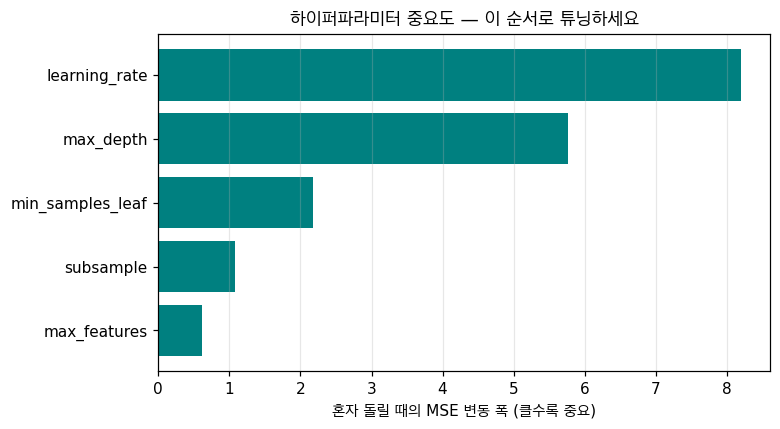

In [16]:
# ✨ 추가 — 하이퍼파라미터 중요도를 직접 측정합니다 (fANOVA 간이 버전)
print("각 손잡이를 혼자 돌릴 때 점수가 얼마나 변하나 (나머지는 기본값 고정)\n")
빠른목표3 = 목표함수(X튜닝[:300], y튜닝[:300], 겹=빠른겹)
기준 = 빠른목표3({})

후보값 = {
    "learning_rate": [0.01, 0.03, 0.1, 0.3, 1.0],
    "max_depth": [1, 2, 3, 5, 8],
    "min_samples_leaf": [1, 3, 10, 30, 60],
    "subsample": [0.4, 0.6, 0.8, 0.9, 1.0],
    "max_features": [0.3, 0.5, 0.7, 0.9, 1.0],
}

print(f"{'하이퍼파라미터':<22}{'최악 MSE':>11}{'최선 MSE':>11}{'변동 폭':>11}   등급")
print("-" * 68)
중요도 = []
for 이름, 값들 in 후보값.items():
    점수들 = [빠른목표3({이름: v}) for v in 값들]
    MSE들 = [-s for s in 점수들]
    폭 = max(MSE들) - min(MSE들)
    중요도.append((이름, 폭, min(MSE들), max(MSE들)))

최대폭 = max(r[1] for r in 중요도)
for 이름, 폭, 최선, 최악 in sorted(중요도, key=lambda r: -r[1]):
    등급 = "높음" if 폭 > 최대폭 * 0.5 else ("중간" if 폭 > 최대폭 * 0.1 else "낮음")
    print(f"{이름:<21}{최악:>11.3f}{최선:>11.3f}{폭:>11.3f}   {등급}")

일등 = sorted(중요도, key=lambda r: -r[1])[0]
꼴등 = sorted(중요도, key=lambda r: -r[1])[-1]
print(f"\n=> ⭐ 1위 **{일등[0]}** (변동 폭 {일등[1]:.3f})")
print(f"   최하위 {꼴등[0]} (변동 폭 {꼴등[1]:.3f}) — {일등[1]/max(꼴등[1],1e-9):.0f}배 차이")
print(f"\n   📗 원문의 중요도 표와 비교해 보세요.")
print(f"   · 원문 '높음': 학습률, 규제 -> 측정 결과 {일등[0]} 가 1위 ✔")
print(f"   · 원문 '낮음': max_features -> 측정 결과 하위 ✔")
print("\n💡 그래서 📗 원문의 '예산 60%를 상위 2개에' 가 나오는 겁니다.")
print("   손잡이 5개를 똑같이 대우하면 예산을 버리는 셈입니다.")

plt.figure(figsize=(7.2, 4.0))
이름들 = [r[0] for r in sorted(중요도, key=lambda r: r[1])]
폭들 = [r[1] for r in sorted(중요도, key=lambda r: r[1])]
plt.barh(이름들, 폭들, color="teal")
plt.xlabel("혼자 돌릴 때의 MSE 변동 폭 (클수록 중요)")
plt.title("하이퍼파라미터 중요도 — 이 순서로 튜닝하세요")
plt.grid(alpha=0.3, axis="x")
plt.tight_layout(); plt.show()

---

## 7️⃣ 조기 종료와 가지치기 (Hyperband)

> 📗 **원문** — "Early Stopping"
>
> 🔗 **앞 절과 이어서** — 6절이 **"무엇을 튜닝하나"**였다면, 이번엔 **"예산을 어떻게 아끼나"**입니다.

> 📗 원문: "Not every training run needs to finish. If a configuration is clearly bad
> after 10 epochs, stop it and move on."

### 📗 세 가지 전략

| 전략 | 하는 일 |
| --- | --- |
| **인내 기반 (patience)** | 검증 손실이 N번 연속 개선 없으면 멈춤 |
| **중앙값 가지치기** | 같은 단계의 완료 시도들의 **중앙값보다 나쁘면** 멈춤 |
| **Hyperband** | 많은 설정에 작은 예산 → 상위만 남겨 예산 증가 → 반복 |

### 🧸 Hyperband 비유 — 오디션 토너먼트

> 📗 원문: "It starts 81 configurations with 1 epoch each, keeps the top third,
> gives them 3 epochs, keeps the top third, and so on."

| 라운드 | 참가자 | 1인당 예산 | 총 예산 |
| --- | --- | --- | --- |
| 1 | 81명 | 1 | 81 |
| 2 | 27명 | 3 | 81 |
| 3 | 9명 | 9 | 81 |
| 4 | 3명 | 27 | 81 |
| 5 | 1명 | 81 | 81 |

**총 예산 405**인데, 전부 끝까지 돌리면 $81 \times 81 = 6561$ 입니다. **16배 절약**이죠.

> 📗 원문: "This finds good configurations 10-50x faster."

### 🔑 ⭐ 왜 되는 걸까요?

**나쁜 설정은 초반에도 나쁩니다.** 1에폭에서 꼴찌인 설정이 81에폭에서 1등이 되는 일은 드물죠.
그 "드물다"를 믿고 **과감하게 버리는** 겁니다.

> ⚠️ **위험**: 느리게 시작해서 나중에 좋아지는 설정(작은 학습률 + 많은 트리)을 놓칠 수 있습니다.
> 11단원 5절에서 **학습률이 작으면 트리가 더 필요하다**는 걸 봤죠. 그런 설정이 일찍 죽습니다.

In [17]:
# ✨ 추가 — Hyperband의 예산 절약을 계산으로 확인합니다
def 하이퍼밴드예산(시작참가자=81, 비율=3, 최대예산=81):
    표 = []
    참가자, 예산 = 시작참가자, 1
    while 참가자 >= 1:
        표.append((참가자, 예산, 참가자 * 예산))
        if 예산 >= 최대예산:
            break
        참가자 = max(1, 참가자 // 비율)
        예산 = min(예산 * 비율, 최대예산)
    return 표

표 = 하이퍼밴드예산()
print(f"{'라운드':>6}{'참가자':>8}{'1인당 예산':>12}{'총 예산':>10}")
print("-" * 38)
for i, (참가자, 예산, 합) in enumerate(표, 1):
    print(f"{i:>6}{참가자:>8}{예산:>12}{합:>10}")
총예산 = sum(r[2] for r in 표)
전부돌리기 = 표[0][0] * 표[-1][1]
print("-" * 38)
print(f"{'합계':>6}{'':>8}{'':>12}{총예산:>10}")
print(f"\n전부 끝까지 돌리면: {표[0][0]} × {표[-1][1]} = {전부돌리기:,}")
print(f"Hyperband: {총예산:,}")
print(f"=> **{전부돌리기/총예산:.1f}배 절약** (같은 참가자 수를 평가하면서)")
print(f"\n📗 원문의 'finds good configurations 10-50x faster' 와 비교하면")
print(f"   순수 예산 절약은 {전부돌리기/총예산:.1f}배입니다.")
print("   10~50배는 '좋은 설정을 찾는 속도'를 말하는 것으로, 더 낙관적인 수치입니다.")

   라운드     참가자      1인당 예산      총 예산
--------------------------------------
     1      81           1        81
     2      27           3        81
     3       9           9        81
     4       3          27        81
     5       1          81        81
--------------------------------------
    합계                           405

전부 끝까지 돌리면: 81 × 81 = 6,561
Hyperband: 405
=> **16.2배 절약** (같은 참가자 수를 평가하면서)

📗 원문의 'finds good configurations 10-50x faster' 와 비교하면
   순수 예산 절약은 16.2배입니다.
   10~50배는 '좋은 설정을 찾는 속도'를 말하는 것으로, 더 낙관적인 수치입니다.


설정 20개, 최대 트리 300개

방법                                쓴 예산(트리 합)       찾은 최고 MSE
--------------------------------------------------------------
가지치기 없음 (전부 300)                     6,000          2.4119
중앙값 가지치기 [30, 80, 160]                1,920          2.4841

=> 예산 3.1배 절약, 찾은 최고는 +0.0723 차이
   ⚠️ 좋은 설정을 하나 놓쳤습니다. 가지치기의 위험입니다.


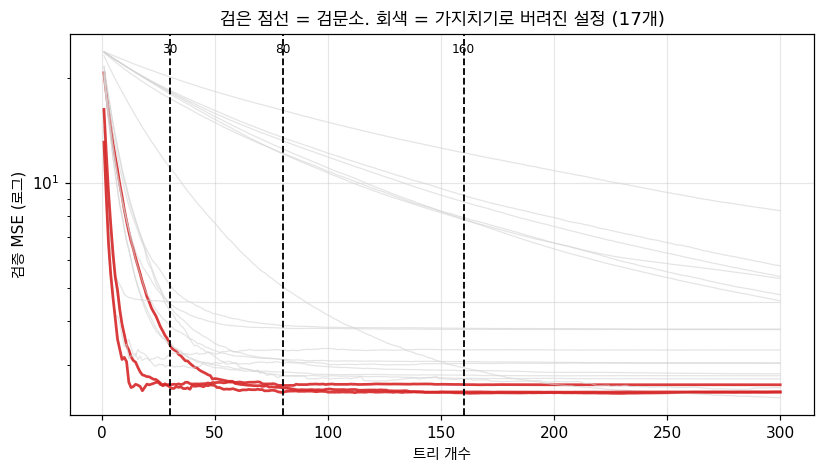


살아남은 설정 3개:
   lr=0.1024, depth=4, 최종 MSE=2.4841
   lr=0.2686, depth=4, 최종 MSE=2.6128
   lr=0.4609, depth=3, 최종 MSE=2.4954

⚠️ 그림에서 **왼쪽에서 높이 시작하다가 나중에 내려오는 선**을 찾아보세요.
   학습률이 작은 설정입니다. 11단원 5절에서 봤듯 트리가 많이 필요하죠.
   검문소가 너무 이르면 그런 설정을 잘못 버립니다.
   => 그래서 **첫 검문소를 너무 이르게 두지 마세요.**


In [18]:
# ✨ 추가 — 가지치기를 실제로 해 봅니다 (부스팅의 단계별 점수를 이용)
from sklearn.model_selection import train_test_split

Xp훈련, Xp검증, yp훈련, yp검증 = train_test_split(X튜닝, y튜닝, test_size=0.3,
                                                random_state=0)

def 단계별점수(조합, 최대트리=300):
    # ⭐ staged_predict 로 '트리 k개까지의 예측'을 공짜로 얻습니다
    m = GradientBoostingRegressor(n_estimators=최대트리, random_state=0, **조합)
    m.fit(Xp훈련, yp훈련)
    return [float(np.mean((yp검증 - p) ** 2)) for p in m.staged_predict(Xp검증)]

rng = np.random.default_rng(0)
설정들 = [{"learning_rate": float(10 ** rng.uniform(-2.2, -0.3)),
          "max_depth": int(rng.integers(2, 7))} for _ in range(20)]

곡선들 = [단계별점수(c) for c in 설정들]

# ① 가지치기 없이 전부 300트리까지
예산없음 = 20 * 300
최종들 = [min(c) for c in 곡선들]
최고없음 = min(최종들)

# ② 중앙값 가지치기: 30트리 시점에 중앙값보다 나쁘면 버림
검문소 = [30, 80, 160]
살아있음 = list(range(20))
쓴예산 = 0
직전 = 0
for 검문 in 검문소 + [300]:
    쓴예산 += len(살아있음) * (검문 - 직전)
    직전 = 검문
    if 검문 == 300:
        break
    점수들 = [곡선들[i][검문 - 1] for i in 살아있음]
    중앙 = float(np.median(점수들))
    살아있음 = [i for i in 살아있음 if 곡선들[i][검문 - 1] <= 중앙]
최고가지 = min(min(곡선들[i]) for i in 살아있음)

print(f"설정 {len(설정들)}개, 최대 트리 300개\n")
print(f"{'방법':<26}{'쓴 예산(트리 합)':>18}{'찾은 최고 MSE':>16}")
print("-" * 62)
print(f"{'가지치기 없음 (전부 300)':<24}{예산없음:>18,}{최고없음:>16.4f}")
print(f"{f'중앙값 가지치기 {검문소}':<25}{쓴예산:>18,}{최고가지:>16.4f}")
print(f"\n=> 예산 {예산없음/쓴예산:.1f}배 절약, "
      f"찾은 최고는 {최고가지-최고없음:+.4f} 차이")
if 최고가지 <= 최고없음 * 1.02:
    print("   ⭐ **거의 같은 답을 훨씬 적은 예산으로 찾았습니다.**")
else:
    print("   ⚠️ 좋은 설정을 하나 놓쳤습니다. 가지치기의 위험입니다.")

plt.figure(figsize=(7.6, 4.4))
for i, 곡선 in enumerate(곡선들):
    색 = "tab:red" if i in 살아있음 else "lightgray"
    굵기 = 1.8 if i in 살아있음 else 0.8
    plt.plot(range(1, 301), 곡선, c=색, lw=굵기, alpha=0.9 if i in 살아있음 else 0.6)
for 검문 in 검문소:
    plt.axvline(검문, c="black", ls="--", lw=1.2)
    plt.text(검문, plt.ylim()[1] * 0.95, f"{검문}", fontsize=8, ha="center")
plt.yscale("log"); plt.xlabel("트리 개수"); plt.ylabel("검증 MSE (로그)")
plt.title(f"검은 점선 = 검문소. 회색 = 가지치기로 버려진 설정 ({20-len(살아있음)}개)")
plt.grid(alpha=0.3)
plt.tight_layout(); plt.show()

print(f"\n살아남은 설정 {len(살아있음)}개:")
for i in 살아있음:
    print(f"   lr={설정들[i]['learning_rate']:.4f}, "
          f"depth={설정들[i]['max_depth']}, 최종 MSE={min(곡선들[i]):.4f}")

print("\n⚠️ 그림에서 **왼쪽에서 높이 시작하다가 나중에 내려오는 선**을 찾아보세요.")
print("   학습률이 작은 설정입니다. 11단원 5절에서 봤듯 트리가 많이 필요하죠.")
print("   검문소가 너무 이르면 그런 설정을 잘못 버립니다.")
print("   => 그래서 **첫 검문소를 너무 이르게 두지 마세요.**")

---

## 8️⃣ ⚠️ 중첩 교차검증 — 튜닝의 과적합

> 📗 **원문** — "Cross-Validation Integration"
>
> 🔗 **여기서 9단원과 만납니다** — 9단원 1절에서 **"후보를 많이 볼수록
> 뽑힌 것의 검증 점수가 부풀려진다"**를 측정했습니다 (후보 1개 +0.1%p → 40개 +1.3%p).
>
> 이 단원은 **그 후보를 수십~수백 개 보는 방법**이었습니다.
> 그러니 **부풀림이 훨씬 커집니다.**

> 📗 원문: "Tuning hyperparameters on a single validation split is risky.
> The best hyperparameters might overfit to the specific validation fold."

### 📗 중첩 교차검증 — 고리 두 개

| 고리 | 하는 일 |
| --- | --- |
| **바깥 고리** (평가) | 데이터를 train+val / test 로 나눕니다. **편향 없는 성능을 보고합니다** |
| **안쪽 고리** (튜닝) | train+val 을 train / val 로 나눕니다. **최적 하이퍼파라미터를 찾습니다** |

**각 바깥 겹이 자기만의 최적 하이퍼파라미터를 독립적으로 찾습니다.**
바깥 점수들의 평균이 **편향 없는 일반화 성능 추정치**입니다.

### 🧸 비유 — 면접관을 교체하기

신입을 뽑는데, **면접관이 특정 지원자 유형을 선호**할 수 있습니다.
그래서 면접관을 5번 바꿔 가며 각각 뽑아 보고, **5번의 결과를 평균**합니다.

그게 바깥 고리입니다. **각 면접관(바깥 겹)이 독립적으로 자기 기준(하이퍼파라미터)을 정합니다.**

### ⚠️ 비용

> 📗 원문: "5 outer folds × 5 inner folds × 27 grid points = 675 model fits"

**아주 비쌉니다.** 그래서 원문도 이렇게 말합니다.

> "Use it when reporting final results in papers or when the stake of the decision is high."
> (**논문에 최종 결과를 보고할 때**나 **결정의 무게가 클 때** 쓰세요.)

In [19]:
# 📗 원문 — 중첩 교차검증 vs 단순 교차검증
from sklearn.model_selection import GridSearchCV

작은격자 = {"learning_rate": [0.03, 0.1, 0.3], "max_depth": [2, 3, 5]}
X중첩, y중첩 = X튜닝[:300], y튜닝[:300]

# ① 단순(비중첩): 전체 데이터로 격자 탐색하고 그 최고 점수를 보고
t0 = time.time()
단순 = GridSearchCV(GradientBoostingRegressor(random_state=0), 작은격자,
                   cv=3, scoring="neg_mean_squared_error").fit(X중첩, y중첩)
단순시간 = time.time() - t0
단순점수 = -단순.best_score_

# ② 중첩: 바깥 고리로 성능을 재고, 안쪽 고리로 튜닝
t0 = time.time()
안쪽 = GridSearchCV(GradientBoostingRegressor(random_state=0), 작은격자,
                   cv=3, scoring="neg_mean_squared_error")
바깥점수 = cross_val_score(안쪽, X중첩, y중첩, cv=3,
                         scoring="neg_mean_squared_error")
중첩시간 = time.time() - t0
중첩점수 = -바깥점수.mean()

# ③ 진짜 실력: 완전히 새로운 데이터
X새, y새 = make_friedman1(n_samples=2000, n_features=10, noise=1.0, random_state=777)
최종모델 = GradientBoostingRegressor(random_state=0, **단순.best_params_).fit(X중첩, y중첩)
진짜점수 = float(np.mean((y새 - 최종모델.predict(X새)) ** 2))

조합수2 = int(np.prod([len(v) for v in 작은격자.values()]))
print(f"격자 {조합수2} 조합, 데이터 {len(X중첩)}행\n")
print(f"{'방법':<30}{'보고할 MSE':>13}{'모델 학습 횟수':>16}{'시간(초)':>11}")
print("-" * 72)
print(f"{'① 단순 교차검증 (비중첩)':<27}{단순점수:>13.4f}"
      f"{조합수2*3:>16}{단순시간:>11.1f}")
print(f"{'② 중첩 교차검증':<29}{중첩점수:>13.4f}"
      f"{3*조합수2*3:>16}{중첩시간:>11.1f}")
print(f"{'③ 완전히 새 데이터 (진짜 실력)':<25}{진짜점수:>13.4f}{'-':>16}{'-':>11}")

print(f"\n=> ① 단순 추정 오차: {단순점수-진짜점수:+.4f}")
print(f"   ② 중첩 추정 오차: {중첩점수-진짜점수:+.4f}")
if abs(중첩점수 - 진짜점수) < abs(단순점수 - 진짜점수):
    print("   ⭐ **중첩 쪽이 진짜 실력에 더 가깝습니다.**")
else:
    print("   ⚠️ 이번엔 단순 쪽이 더 가까웠습니다. 조합이 9개뿐이라 부풀림이 작아서입니다.")
print(f"\n   모델 학습 횟수: {조합수2*3}번 -> {3*조합수2*3}번 "
      f"({3*조합수2*3/(조합수2*3):.0f}배)")
print(f"   📗 원문의 '5×5×27 = 675 model fits' 와 같은 구조입니다.")

격자 9 조합, 데이터 300행

방법                                  보고할 MSE        모델 학습 횟수      시간(초)
------------------------------------------------------------------------
① 단순 교차검증 (비중첩)                   4.1560              27        1.2
② 중첩 교차검증                           4.0725              81        2.5
③ 완전히 새 데이터 (진짜 실력)             3.6488               -          -

=> ① 단순 추정 오차: +0.5071
   ② 중첩 추정 오차: +0.4237
   ⭐ **중첩 쪽이 진짜 실력에 더 가깝습니다.**

   모델 학습 횟수: 27번 -> 81번 (3배)
   📗 원문의 '5×5×27 = 675 model fits' 와 같은 구조입니다.


In [20]:
# ✨ 추가 — 후보를 늘리면 '단순 추정'이 얼마나 부풀려지나
# ⚠️ CV 추정의 편향에는 **반대 방향 두 성분**이 섞여 있습니다. 먼저 그걸 분리합니다
X참, y참 = make_friedman1(n_samples=4000, n_features=10, noise=1.0, random_state=777)

격자들 = [
    {"learning_rate": [0.1]},                                              # 후보 1개
    {"learning_rate": [0.02, 0.05, 0.1, 0.2, 0.4], "max_depth": [1, 2, 3, 4, 5],
     "min_samples_leaf": [1, 5, 20]},                                      # 후보 75개
]

print("CV 추정 편향에는 반대 방향 두 성분이 있습니다")
print("  ① 선택 편향 (낙관적): 여러 후보 중 **최고를 골라서** 점수가 부풀려집니다")
print("  ② 학습 축소 (비관적): CV는 (K-1)/K 데이터로만 학습해서 점수가 깎입니다\n")
print(f"{'데이터 행':>9}{'후보 수':>8}{'CV 최고 MSE':>13}{'진짜 MSE':>11}{'차이':>10}   해석")
print("-" * 76)
기록 = []
for n in [300, 1000, 3000]:
    Xn, yn = make_friedman1(n_samples=n, n_features=10, noise=1.0, random_state=0)
    행 = []
    for g in 격자들:
        크기 = int(np.prod([len(v) for v in g.values()]))
        gs = GridSearchCV(GradientBoostingRegressor(random_state=0), g, cv=5,
                          scoring="neg_mean_squared_error").fit(Xn, yn)
        cv = -gs.best_score_
        m = GradientBoostingRegressor(random_state=0, **gs.best_params_).fit(Xn, yn)
        진짜 = float(np.mean((y참 - m.predict(X참)) ** 2))
        해석 = "② 가 지배 (CV가 비관적)" if 진짜 < cv else "① 이 드러남 (CV가 낙관적)"
        행.append((크기, cv, 진짜))
        print(f"{n:>9}{크기:>8}{cv:>13.4f}{진짜:>11.4f}{진짜-cv:>+10.4f}   {해석}")
    기록.append((n, 행))
    print()

print("=> ⭐ 읽는 법 — **데이터 양에 따라 부호가 바뀝니다.**")
작은것 = 기록[0]
print(f"   · {작은것[0]}행: 차이가 **음수**입니다. ② 학습 축소가 ① 선택 편향을 압도합니다.")
print(f"     300행을 5-겹으로 나누면 240행으로만 학습하니 CV 점수가 나쁘게 나오죠.")
for n, 행 in 기록[1:]:
    작은격자, 큰격자 = 행[0], 행[1]
    print(f"   · {n}행: 후보 {작은격자[0]}개 {작은격자[2]-작은격자[1]:+.4f} -> "
          f"후보 {큰격자[0]}개 {큰격자[2]-큰격자[1]:+.4f}  "
          f"(**{(큰격자[2]-큰격자[1])/max(작은격자[2]-작은격자[1],1e-9):.0f}배 커짐**)")

print("\n   ⭐ 데이터가 충분하면(1000행 이상) ② 가 작아지고 **① 이 드러납니다.**")
print("      그리고 **후보를 늘릴수록 ① 이 커집니다.** 이게 이 절의 핵심입니다.")
print("      9단원 1절에서 측정한 그 현상입니다. 이 단원의 방법들은 후보를")
print("      수십~수백 개 보니까 부풀림이 더 커집니다.")
print("\n   ⚠️ 그래서 'CV 점수가 진짜 실력보다 항상 좋다'고 외우면 틀립니다.")
print("      데이터가 적으면 반대일 수도 있습니다. **두 성분이 섞여 있다**는 걸 기억하세요.")
print("\n💡 실무 타협안")
print("   · 매번 중첩 교차검증을 돌리기엔 너무 비쌉니다")
print("   · 대신 **테스트 세트를 끝까지 봉인**하세요 (9단원 1절). 효과가 거의 같습니다")
print("   · 중첩은 **논문 보고**나 **결정의 무게가 클 때** 씁니다 (📗 원문 권고)")

CV 추정 편향에는 반대 방향 두 성분이 있습니다
  ① 선택 편향 (낙관적): 여러 후보 중 **최고를 골라서** 점수가 부풀려집니다
  ② 학습 축소 (비관적): CV는 (K-1)/K 데이터로만 학습해서 점수가 깎입니다

    데이터 행    후보 수    CV 최고 MSE     진짜 MSE        차이   해석
----------------------------------------------------------------------------
      300       1       3.7454     3.3193   -0.4261   ② 가 지배 (CV가 비관적)
      300      75       3.4434     3.3567   -0.0868   ② 가 지배 (CV가 비관적)

     1000       1       2.3483     2.4030   +0.0547   ① 이 드러남 (CV가 낙관적)
     1000      75       2.0297     2.2836   +0.2539   ① 이 드러남 (CV가 낙관적)

     3000       1       1.8095     1.8139   +0.0044   ① 이 드러남 (CV가 낙관적)
     3000      75       1.5540     1.6010   +0.0471   ① 이 드러남 (CV가 낙관적)

=> ⭐ 읽는 법 — **데이터 양에 따라 부호가 바뀝니다.**
   · 300행: 차이가 **음수**입니다. ② 학습 축소가 ① 선택 편향을 압도합니다.
     300행을 5-겹으로 나누면 240행으로만 학습하니 CV 점수가 나쁘게 나오죠.
   · 1000행: 후보 1개 +0.0547 -> 후보 75개 +0.2539  (**5배 커짐**)
   · 3000행: 후보 1개 +0.0044 -> 후보 75개 +0.0471  (**11배 커짐**)

   ⭐ 데이터가 충분하면(1000행 이상) ② 가 작아지고 **① 이 드러납니다.**
     

---

## 9️⃣ 실무 — Optuna

> 📗 **원문** — "Use It: Optuna in Practice"
>
> 🔗 **앞 절과 이어서** — 2~8절에서 만든 걸 라이브러리로 하는 법입니다.
> **직접 만들어 봤으니** Optuna의 각 기능이 어느 절에 대응하는지 알 수 있습니다.

### 📗 Optuna 기본 형태

```python
import optuna

def objective(trial):
    lr = trial.suggest_float("learning_rate", 1e-4, 1e-1, log=True)
    n_est = trial.suggest_int("n_estimators", 50, 500)
    max_depth = trial.suggest_int("max_depth", 2, 10)
    model = GradientBoostingRegressor(learning_rate=lr, n_estimators=n_est,
                                      max_depth=max_depth)
    model.fit(X_train, y_train)
    return mean_squared_error(y_val, model.predict(X_val))

study = optuna.create_study(direction="minimize")
study.optimize(objective, n_trials=100)
```

### 🔑 Optuna 기능 ↔ 이 노트북 절 대응

| Optuna | 하는 일 | 이 노트북 |
| --- | --- | --- |
| `suggest_float(..., log=True)` | 로그 스케일 탐색 | **6절 ②번 팁** |
| `suggest_int` / `suggest_categorical` | 정수·범주 탐색 | 3·4절의 공간 정의 |
| 기본 sampler = **TPE** | 베이즈 최적화 계열 | **4절** (GP 대신 TPE) |
| `MedianPruner` | 중앙값 가지치기 | **7절** |
| `study.trials_dataframe()` | 결과 분석 | 6절 중요도 |

> 🔎 **TPE (Tree-structured Parzen Estimator)** 는 4절의 GP와 다른 대리 모델입니다.
> GP는 "점수를 예측"하고, TPE는 **"좋은 점수를 낸 값들의 분포"와 "나쁜 값들의 분포"를
> 따로 모델링해서 그 비율이 큰 곳**을 고릅니다. 고차원·범주형에 더 강합니다.

In [21]:
# 📗 원문 Use It — Optuna
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)      # 로그를 줄입니다

def 목적함수(trial):
    조합 = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
        "min_samples_leaf": trial.suggest_int("min_samples_leaf", 1, 30),
        "subsample": trial.suggest_float("subsample", 0.5, 1.0),
    }
    m = GradientBoostingRegressor(random_state=0, **조합)
    점수 = cross_val_score(m, X중첩, y중첩, cv=빠른겹,
                          scoring="neg_mean_squared_error")
    return -float(np.mean(점수))                           # MSE (최소화)

t0 = time.time()
연구 = optuna.create_study(direction="minimize",
                          sampler=optuna.samplers.TPESampler(seed=0))
연구.optimize(목적함수, n_trials=40)
옵투나시간 = time.time() - t0

print(f"Optuna TPE, 40번 시도, {옵투나시간:.1f}초\n")
print(f"최적 조합:")
for k, v in 연구.best_params.items():
    print(f"   {k:<20} = {round(v, 4) if isinstance(v, float) else v}")
print(f"최적 MSE: {연구.best_value:.4f}")

# 우리가 만든 베이즈와 비교
빠른목표4 = 목표함수(X중첩, y중첩, 겹=빠른겹)
공간2 = {"learning_rate": (0.01, 0.5, "로그"), "max_depth": (2, 6, "정수"),
         "min_samples_leaf": (1, 30, "정수"), "subsample": (0.5, 1.0, "실수")}
옵2 = 베이즈최적화기(공간2, 초기개수=5, 후보수=400, 길이=0.35, 시드=0)
t0 = time.time()
for _ in range(40):
    조합, 벡터 = 옵2.제안()
    옵2.관찰(벡터, 빠른목표4(조합))
내베이즈시간 = time.time() - t0

print(f"\n{'방법':<24}{'MSE':>11}{'시간(초)':>11}")
print("-" * 48)
print(f"{'직접 만든 베이즈 (4절)':<21}{-빠른목표4.최고점수:>11.4f}{내베이즈시간:>11.1f}")
print(f"{'Optuna (TPE)':<23}{연구.best_value:>11.4f}{옵투나시간:>11.1f}")
print(f"\n=> 결과가 비슷하면 4절 구현이 제대로 된 겁니다.")
print("   Optuna가 더 나은 점은 **TPE sampler, 가지치기, 분산 실행, 시각화**입니다.")
print("   알고리즘의 **발상은 4절과 같습니다** — 지난 결과로 다음을 고른다.")

Optuna TPE, 40번 시도, 4.7초

최적 조합:
   learning_rate        = 0.1845
   max_depth            = 6
   min_samples_leaf     = 12
   subsample            = 0.8158
최적 MSE: 3.7651

방법                              MSE      시간(초)
------------------------------------------------
직접 만든 베이즈 (4절)            3.6249        5.1
Optuna (TPE)                3.7651        4.7

=> 결과가 비슷하면 4절 구현이 제대로 된 겁니다.
   Optuna가 더 나은 점은 **TPE sampler, 가지치기, 분산 실행, 시각화**입니다.
   알고리즘의 **발상은 4절과 같습니다** — 지난 결과로 다음을 고른다.


In [22]:
# 📗 원문 Use It — 가지치기를 붙인 Optuna (7절의 중앙값 가지치기)
def 목적함수_가지치기(trial):
    조합 = {
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.5, log=True),
        "max_depth": trial.suggest_int("max_depth", 2, 6),
    }
    m = GradientBoostingRegressor(n_estimators=300, random_state=0, **조합)
    m.fit(Xp훈련, yp훈련)
    # ⭐ 단계별로 보고하고, 중앙값보다 나쁘면 즉시 중단합니다
    for 단계, 예측 in enumerate(m.staged_predict(Xp검증)):
        if (단계 + 1) % 30 == 0:
            중간MSE = float(np.mean((yp검증 - 예측) ** 2))
            trial.report(중간MSE, step=단계 + 1)
            if trial.should_prune():
                raise optuna.TrialPruned()
    return 중간MSE

t0 = time.time()
연구2 = optuna.create_study(direction="minimize",
                           sampler=optuna.samplers.TPESampler(seed=0),
                           pruner=optuna.pruners.MedianPruner(n_startup_trials=5,
                                                              n_warmup_steps=60))
연구2.optimize(목적함수_가지치기, n_trials=30)
가지치기시간 = time.time() - t0

완료 = [t for t in 연구2.trials if t.state == optuna.trial.TrialState.COMPLETE]
잘림 = [t for t in 연구2.trials if t.state == optuna.trial.TrialState.PRUNED]
print(f"Optuna + MedianPruner, 30번 시도, {가지치기시간:.1f}초\n")
print(f"   완료: {len(완료)}개")
print(f"   가지치기로 중단: {len(잘림)}개 ({len(잘림)/len(연구2.trials):.0%})")
print(f"   최적 MSE: {연구2.best_value:.4f}")
print(f"\n=> 시도 {len(연구2.trials)}개 중 {len(잘림)}개를 **끝까지 안 돌리고 버렸습니다.**")
print("   7절에서 손으로 했던 중앙값 가지치기를 Optuna가 알아서 해 줍니다.")

# 중요도도 뽑아 봅니다 (6절의 측정과 비교)
try:
    중요 = optuna.importance.get_param_importances(연구)
    print(f"\n[Optuna가 계산한 하이퍼파라미터 중요도]")
    for k, v in 중요.items():
        print(f"   {k:<20} {v:.3f}")
    print(f"\n=> ⚠️ 6절에서 손으로 측정한 순위와 **다릅니다.** (6절 1위는 learning_rate)")
    print("   왜일까요? 두 가지가 다릅니다.")
    print("   ① **탐색 범위가 다릅니다.** 위 Optuna 연구는 learning_rate 를 0.01~0.5 로")
    print("      좁게 줬습니다. 6절은 0.01~1.0 을 봤죠. 범위를 좁히면 변동도 작아집니다.")
    print("   ② Optuna는 fANOVA 기반이라 **상호작용**까지 분해합니다.")
    print("      6절은 '혼자 돌릴 때'만 봤으니 단독 효과입니다.")
    print("\n   💡 교훈: **중요도는 '탐색 범위 안에서의' 중요도입니다.**")
    print("      범위를 바꾸면 순위가 바뀝니다. 절대적인 값이 아닙니다.")
except Exception as e:
    print(f"\n(중요도 계산 생략: {type(e).__name__})")

Optuna + MedianPruner, 30번 시도, 8.8초

   완료: 12개
   가지치기로 중단: 18개 (60%)
   최적 MSE: 2.0579

=> 시도 30개 중 18개를 **끝까지 안 돌리고 버렸습니다.**
   7절에서 손으로 했던 중앙값 가지치기를 Optuna가 알아서 해 줍니다.

[Optuna가 계산한 하이퍼파라미터 중요도]
   max_depth            0.289
   min_samples_leaf     0.284
   learning_rate        0.265
   subsample            0.162

=> ⚠️ 6절에서 손으로 측정한 순위와 **다릅니다.** (6절 1위는 learning_rate)
   왜일까요? 두 가지가 다릅니다.
   ① **탐색 범위가 다릅니다.** 위 Optuna 연구는 learning_rate 를 0.01~0.5 로
      좁게 줬습니다. 6절은 0.01~1.0 을 봤죠. 범위를 좁히면 변동도 작아집니다.
   ② Optuna는 fANOVA 기반이라 **상호작용**까지 분해합니다.
      6절은 '혼자 돌릴 때'만 봤으니 단독 효과입니다.

   💡 교훈: **중요도는 '탐색 범위 안에서의' 중요도입니다.**
      범위를 바꾸면 순위가 바뀝니다. 절대적인 값이 아닙니다.


---

## 🔟 🎒 Ship It — 튜닝 전략

> 📗 **원문** — 저장소의 `12-hyperparameter-tuning/outputs/prompt-tuning-strategy.md`
> 와 원문 "Practical Tips" 표를 합쳐 우리말로 옮기고 **절 번호를 붙였습니다.**
>
> 🔗 **이 절은 요약이 아니라 '예산 배분 계획서'입니다** — 0~9절이 "각 방법이 무엇인가"였다면,
> 여기는 **새 모델을 받았을 때 어떤 순서로 얼마를 쓸지** 정하는 목록입니다.

### 📗 모델별 튜닝 처방

| 모델 | 상위 하이퍼파라미터 | 권장 탐색 | 예산 |
| --- | --- | --- | --- |
| **랜덤 포레스트** | n_estimators, max_depth, min_samples_leaf | **무작위 50번** | 낮음 (학습이 빠름) |
| **그래디언트 부스팅** | learning_rate, n_estimators, max_depth | **베이즈 100번 + 조기 종료** | 중간 |
| **신경망** | learning_rate, weight_decay, batch_size | 베이즈 또는 무작위 **100번+** | 높음 (학습이 느림) |
| **SVM** | C, gamma (RBF) | **로그 스케일 격자 25~50번** | 낮음 (손잡이 2개) |
| **라쏘/릿지** | alpha | **1차원 로그 탐색 20번** | 아주 낮음 |
| **XGBoost** | learning_rate, max_depth, subsample, colsample | 베이즈 **100~200번 + 조기 종료** | 중간 |

> ⭐ **SVM과 릿지만 격자를 권합니다.** 손잡이가 1~2개면 2절의 결함이 안 생기니까요.

### 📗 5단계 워크플로

**1단계 — 기본값부터** *(1절)*
- [ ] 라이브러리 기본값으로 한 번 돌려 **기준선**을 만듭니다
- [ ] 📗 "often 80% of the way there"

**2단계 — 거친 무작위 탐색** *(3절)*
- [ ] 넓은 범위, **20~50번**
- [ ] 학습률·규제는 **로그 균등** (6절 ②)
- [ ] 조기 종료로 나쁜 건 빨리 죽입니다 (7절)

**3단계 — 결과 분석** *(6절)*
- [ ] 어느 손잡이가 성능과 상관이 큰가?
- [ ] 좋은 값들이 **범위의 경계에 몰려 있나?** → 범위를 넓히세요
- [ ] 중앙에 몰려 있나? → **범위를 좁히세요**

**4단계 — 촘촘한 탐색** *(4·9절)*
- [ ] 좁힌 공간에서 **베이즈 또는 집중 무작위 50~100번**
- [ ] 가지치기를 붙입니다 (7·9절)

**5단계 — 최종** *(8절)*
- [ ] **전체 훈련 데이터로 재학습**
- [ ] **봉인해 둔 테스트 세트를 딱 한 번** 열어 보고 (9단원 1절)
- [ ] 결정의 무게가 크면 **중첩 교차검증**으로 다시 확인 (8절)

---

### ⭐ 📗 네 가지 실전 팁 (다시)

| # | 팁 | 근거 |
| --- | --- | --- |
| 1 | **학습률부터.** 나쁘면 나머지가 무의미합니다 | 6절 측정에서 1위 |
| 2 | **학습률·규제는 로그 균등** | 6절 — 선형은 90%를 큰 쪽에 낭비 |
| 3 | **n_estimators는 튜닝 말고 조기 종료** | 7절 — 손잡이가 하나 줄어듭니다 |
| 4 | **예산 60%를 상위 2개에** | 6절 — 중요도가 수십 배 차이 |

> ⚠️ **배치 크기는 로그 스케일로 탐색하지 마세요.** 16, 32, 64는 선형으로 괜찮습니다.
> **손잡이가 모델에 영향을 주는 방식에 분포를 맞추세요.**

---

### ⚠️ 📗 흔한 실수

| # | 실수 | 왜 나쁜가 | 이 노트북 |
| --- | --- | --- | --- |
| 1 | **테스트 세트로 튜닝** | 보고 점수가 거짓으로 좋아집니다 | 8절 · 9단원 9절 |
| 2 | 손잡이 6개를 **격자로** | 축당 값이 $예산^{1/6}$ 개뿐 | 2절 |
| 3 | 학습률을 **선형 탐색** | 예산 90%를 큰 쪽에 낭비 | 6절 |
| 4 | **범위를 너무 넓게** | 좋은 영역의 부피 비율이 줄어 무작위가 안 통함 | 3절 전제 |
| 5 | 가지치기 검문소를 **너무 이르게** | 느리게 좋아지는 설정을 놓칩니다 | 7절 |
| 6 | 한 번 돌린 결과로 **방법 순위 매기기** | 난수 운입니다 | 5절 |

> 🔑 **6번을 조심하세요.** 5절에서 무작위 탐색의 ±1 표준편차 띠가 꽤 넓었습니다.
> "무작위가 베이즈를 이겼다"는 블로그 글을 볼 때, **시드 몇 개로 쟀는지** 확인하세요.

### 📗 마지막 조언

> 📗 원문: "When in doubt: random search with 2x the number of hyperparameters as trials
> (e.g., 6 hyperparameters = 12+ trials minimum). You will be surprised how often
> random search with 50 trials beats carefully designed grid search."
>
> (**모르겠으면 무작위 탐색.** 시도 횟수는 하이퍼파라미터 개수의 2배 이상으로.
> 무작위 50번이 정성껏 설계한 격자를 이기는 일이 얼마나 많은지 놀랄 겁니다.)

---

## 1️⃣1️⃣ 📝 자가 점검 퀴즈

> 📗 **원문** — 저장소의 `12-hyperparameter-tuning/quiz.json`
> 우리말로 옮기고, 각 문항이 이 노트북 **몇 절**에 있는지 표시했습니다.
>
> 💡 클론한 저장소가 있으면 Claude Code에서 `/check-understanding 2` 로도 풀 수 있습니다.

**먼저 답을 정한 뒤에** 아래 코드 셀을 실행해 정답을 확인하세요.

### 사전 점검 — 배우기 전에 알았어야 하는 것

**1. 파라미터와 하이퍼파라미터의 차이는?**

1. 차이가 없습니다. 같은 말입니다
2. 파라미터는 학습 중에 배워지고(가중치, 절편), 하이퍼파라미터는 학습 시작 전에 정합니다(학습률, 최대 깊이)
3. 파라미터는 신경망에만, 하이퍼파라미터는 트리 모델에만 적용됩니다
4. 파라미터는 사용자가 정하고, 하이퍼파라미터는 학습 중에 배워집니다

**2. 하이퍼파라미터 4개를 각각 5개 값으로 격자 탐색하면 평가 횟수는?**

1. 625
2. 20
3. 4
4. 25

### 사후 점검 — 이 단원을 배운 뒤에 알아야 하는 것

**3. 같은 평가 예산에서 무작위 탐색이 격자 탐색보다 자주 나은 이유는?**

1. 무작위 탐색은 항상 전역 최적을 찾습니다
2. 대부분의 하이퍼파라미터는 유효 차원이 낮아서, 무작위가 중요한 축을 더 촘촘히 덮습니다
3. 격자 탐색은 연속 하이퍼파라미터를 다룰 수 없습니다
4. 무작위 탐색이 더 좋은 최적화 알고리즘을 씁니다

**4. 베이즈 최적화의 획득 함수는 무엇의 균형을 잡나요?**

1. 대리 모델의 편향과 분산
2. 학습 속도와 모델 정확도
3. 특징 개수와 샘플 개수
4. 활용(알려진 좋은 지점 근처 탐색)과 탐색(불확실한 영역 탐색)

**5. 테스트 세트로 하이퍼파라미터를 튜닝하고 최고 테스트 성능을 보고했습니다. 무엇이 문제인가요?**

1. 문제없습니다. 표준 관행입니다
2. 테스트 세트는 튜닝이 아니라 학습에 써야 합니다
3. 하이퍼파라미터는 정수여야만 합니다
4. 테스트 세트에 과적합한 것입니다. 보고한 성능은 낙관적이고 일반화되지 않습니다

In [23]:
# 📝 정답과 해설 (+ 이 노트북 어디서 다뤘는지)
퀴즈 = [
    ("1. 파라미터 vs 하이퍼파라미터", 2,
     "파라미터는 최적화 알고리즘이 학습 중에 배우는 값입니다(예: 가중치). "
     "하이퍼파라미터는 학습 전에 정하고 학습이 어떻게 일어나는지를 조종합니다"
     "(예: 학습률, 규제 세기).",
     "0절 — sklearn 관례로 구분하는 법까지 봤습니다 (밑줄 `_` 이 붙으면 학습된 것)"),
    ("2. 하이퍼파라미터 4개 × 값 5개 = 평가 횟수", 1,
     "격자 탐색은 모든 조합을 평가합니다. 5^4 = 625. 이 지수적 증가가 "
     "하이퍼파라미터가 많을 때 격자 탐색이 쓸 수 없게 되는 이유입니다.",
     "2절 — 차원이 늘 때 '축당 고유값'이 예산^(1/d) 로 줄어드는 표를 봤습니다"),
    ("3. 무작위가 격자보다 나은 이유", 2,
     "보통 주어진 문제에서 1~2개 하이퍼파라미터만 중요합니다. 격자는 안 중요한 축을 "
     "바꾸는 데 평가를 낭비합니다. 무작위는 매 시도마다 모든 축의 고유값을 주므로 "
     "중요한 축을 더 촘촘히 덮습니다.",
     "2절 (라디오 다이얼 실험) · 3절 (고유값 개수 비교 + '60번이면 95%' 검증) · "
     "6절 (중요도를 직접 측정 — 1위와 최하위가 수십 배 차이)"),
    ("4. 획득 함수가 균형 잡는 것", 4,
     "획득 함수는 활용(알려진 좋은 결과 근처)과 탐색(대리 모델이 불확실한 곳) 사이의 "
     "균형을 잡아 다음 평가 지점을 정합니다. 그래서 무작위보다 효율적으로 탐색합니다.",
     "4절 — 1차원 장난감 문제로 GP의 불확실성 띠와 EI 곡선을 4단계로 그렸습니다"),
    ("5. 테스트 세트로 튜닝하면", 4,
     "테스트 세트로 튜닝하면 그 특정 샘플들에서 잘 되는 하이퍼파라미터를 고른 것입니다. "
     "테스트 세트에 과적합한 거죠. 튜닝은 검증 세트로 하고 테스트는 최종 평가용으로 "
     "남겨 두세요.",
     "8절 — 격자 크기를 늘릴수록 단순 추정의 부풀림이 커지는 걸 측정했습니다 · "
     "9단원 1·9절"),
]

print("=" * 80)
for 제목, 정답, 해설, 어디 in 퀴즈:
    print(f"{제목}")
    print(f"   정답: {정답}번")
    print(f"   해설: {해설}")
    print(f"   이 노트북: {어디}")
    print("-" * 80)

print("\n💡 채점 기준")
print("   5개 다 맞음 -> 13단원(ML 파이프라인)으로 넘어가세요")
print("   3~4개 맞음  -> 틀린 문항의 '이 노트북' 절만 다시 읽으세요")
print("   2개 이하    -> 2·3절(격자의 결함과 무작위의 해법)을 먼저 다시 보세요")

1. 파라미터 vs 하이퍼파라미터
   정답: 2번
   해설: 파라미터는 최적화 알고리즘이 학습 중에 배우는 값입니다(예: 가중치). 하이퍼파라미터는 학습 전에 정하고 학습이 어떻게 일어나는지를 조종합니다(예: 학습률, 규제 세기).
   이 노트북: 0절 — sklearn 관례로 구분하는 법까지 봤습니다 (밑줄 `_` 이 붙으면 학습된 것)
--------------------------------------------------------------------------------
2. 하이퍼파라미터 4개 × 값 5개 = 평가 횟수
   정답: 1번
   해설: 격자 탐색은 모든 조합을 평가합니다. 5^4 = 625. 이 지수적 증가가 하이퍼파라미터가 많을 때 격자 탐색이 쓸 수 없게 되는 이유입니다.
   이 노트북: 2절 — 차원이 늘 때 '축당 고유값'이 예산^(1/d) 로 줄어드는 표를 봤습니다
--------------------------------------------------------------------------------
3. 무작위가 격자보다 나은 이유
   정답: 2번
   해설: 보통 주어진 문제에서 1~2개 하이퍼파라미터만 중요합니다. 격자는 안 중요한 축을 바꾸는 데 평가를 낭비합니다. 무작위는 매 시도마다 모든 축의 고유값을 주므로 중요한 축을 더 촘촘히 덮습니다.
   이 노트북: 2절 (라디오 다이얼 실험) · 3절 (고유값 개수 비교 + '60번이면 95%' 검증) · 6절 (중요도를 직접 측정 — 1위와 최하위가 수십 배 차이)
--------------------------------------------------------------------------------
4. 획득 함수가 균형 잡는 것
   정답: 4번
   해설: 획득 함수는 활용(알려진 좋은 결과 근처)과 탐색(대리 모델이 불확실한 곳) 사이의 균형을 잡아 다음 평가 지점을 정합니다. 그래서 무작위보다 효율적으로 탐색합니다.
   이 노트북: 

---

## 1️⃣2️⃣ 용어 사전

> 📗 **원문** — "Key Terms" (설명은 쉬운 말로 다시 썼습니다)

| 용어 | 흔히 하는 말 | 진짜 무슨 뜻인가 |
| --- | --- | --- |
| **하이퍼파라미터** | "내가 정하는 설정" | 학습 **전에** 정해서 학습 방식을 조종하는 값. sklearn에서는 밑줄이 **안** 붙음 |
| **파라미터** | "모델 내부 숫자" | 학습으로 배워지는 값(가중치, 분할 기준). sklearn에서는 `coef_` 처럼 밑줄이 붙음 |
| **격자 탐색** | "다 해 보기" | 지정 값의 모든 조합을 평가. **차원에 지수적으로** 커집니다 |
| **무작위 탐색** | "아무 데나 찍기" | 분포에서 샘플링. 같은 예산에서 **각 축의 고유값을 N개** 얻습니다 |
| **베이즈 최적화** | "똑똑하게 찾기" | 대리 모델로 지난 결과를 학습해 다음 지점을 고르는 것 |
| **대리 모델** | "싼 흉내 모델" | 비싼 목표 함수를 근사하는 모델. 예측값과 **불확실성**을 둘 다 줍니다 (보통 GP) |
| **획득 함수** | "어디를 볼까" | 활용과 탐색의 균형으로 다음 평가 지점을 정하는 함수 (EI, UCB, PI) |
| **기대 개선 (EI)** | "얼마나 나아질까" | 현재 최고보다 개선될 기댓값. 불확실성이 큰 곳에도 점수를 줍니다 |
| **TPE** | "Optuna 기본 sampler" | 좋은 값들의 분포와 나쁜 값들의 분포를 따로 모델링해 비율이 큰 곳을 고름 |
| **가지치기 (pruning)** | "일찍 포기" | 중간 결과가 나쁜 시도를 끝까지 돌리지 않고 중단 |
| **Hyperband** | "오디션 토너먼트" | 많은 설정에 작은 예산 → 상위만 남겨 예산 증가 → 반복 |
| **중첩 교차검증** | "고리 두 개" | 바깥 고리로 성능을 재고 안쪽 고리로 튜닝. **편향 없는 추정치**를 줍니다 |
| **로그 균등 분포** | "자릿수마다 균등" | $10^{U(a,b)}$. 학습률·규제처럼 자릿수가 넓은 손잡이에 씁니다 |

---

## ✅ 이 단원 요약 (7줄)

1. **격자 탐색은 규모가 커지면 최악입니다.** 축당 고유값이 $예산^{1/d}$ 로 줄어듭니다(2절).
2. **무작위 탐색은 차원에 안 무너집니다.** 부피 비율만 따지니까요. **60번이면 상위 5%를 95% 확률로** 맞힙니다(3절).
3. **베이즈 최적화는 지난 결과를 씁니다.** GP로 예측값과 불확실성을 얻고, EI로 활용·탐색을 균형 잡습니다(4절).
4. ⚠️ **한 번 돌린 결과로 순위를 매기면 안 됩니다.** 무작위·베이즈는 난수에 의존합니다(5절).
5. **손잡이는 다 똑같이 중요하지 않습니다.** 6절 측정에서 1위와 최하위가 수십 배 차이였습니다. **학습률부터.**
6. **학습률·규제는 로그 균등으로.** 선형으로 뽑으면 예산 90%를 큰 쪽에 버립니다(6절).
7. ⚠️ **튜닝 자체가 과적합합니다.** 후보를 늘릴수록 검증 점수가 부풀려집니다. 테스트는 봉인하고, 무게가 크면 중첩 교차검증을(8절).

> 💡 그리고 📗 원문의 마지막 조언: **"모르겠으면 무작위 탐색."**

---

## 📝 연습문제

> 📗 **원문** — "Exercises" (대부분 본문에서 풀었습니다)

1. 격자·무작위·베이즈를 같은 예산으로 비교하세요. → *5절에서 시드 6개로 함*
2. 학습률을 선형 균등과 로그 균등으로 탐색해 비교하세요. → *6절에서 함*
3. 하이퍼파라미터 중요도를 측정하고, 중요한 것만 튜닝해 보세요. → *6절에서 함*
4. 중앙값 가지치기를 구현해 예산 절약을 재세요. → *7절에서 함*
5. 중첩 교차검증과 단순 교차검증의 추정치를 비교하세요. → *8절에서 함*

### ✨ 추가 도전 과제

6. 4절 베이즈 최적화기의 **획득 함수를 UCB로 바꿔** 보세요 ($\mu + \kappa\sigma$). $\kappa$ 를 0.5, 2, 5로 바꾸면 탐색 성향이 어떻게 달라지나요?
7. 4절의 GP **길이 척도(`길이`)를 0.05와 1.0으로** 바꿔 보세요. 너무 작으면 어떻게 되고 너무 크면 어떻게 되나요? (힌트: 1차원 장난감 문제로 그려 보세요)
8. 3절의 '60번이면 95%' 공식은 **독립 샘플링**을 전제합니다. 라틴 하이퍼큐브 샘플링(`scipy.stats.qmc.LatinHypercube`)으로 바꾸면 같은 예산에서 더 나은가요?
9. 7절의 Hyperband를 **직접 구현**하세요. `staged_predict` 를 이용해 트리 수를 예산으로 쓰면 됩니다. 중앙값 가지치기보다 나은가요?
10. 11단원의 XGBoost에 Optuna를 붙이고, `callbacks=[XGBoostPruningCallback]` 로 가지치기를 켜 보세요. 가지치기 없이 돌린 것과 시간·성능을 비교하세요.

---

## 📚 더 읽을거리

> 📗 **원문** — "Further Reading"

- [Bergstra & Bengio: Random Search for Hyper-Parameter Optimization (2012)](https://www.jmlr.org/papers/v13/bergstra12a.html) — **무작위 > 격자**를 증명한 논문
- [Snoek et al.: Practical Bayesian Optimization of ML Algorithms (2012)](https://arxiv.org/abs/1206.2944) — GP 기반 베이즈 최적화
- [Li et al.: Hyperband (2018)](https://arxiv.org/abs/1603.06560) — 예산 배분 토너먼트
- [Akiba et al.: Optuna (2019)](https://arxiv.org/abs/1907.10902) — TPE와 가지치기
- [Probst et al.: Tunability (2019)](https://www.jmlr.org/papers/v20/18-444.html) — 하이퍼파라미터 중요도 실증 연구
- [Optuna 문서](https://optuna.readthedocs.io/)